# Preamble
---
This section imports all relevant libraries and defines all data loading functions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import glob
from pathlib import Path
import re

import pvlib
from scipy.signal import hilbert
from scipy import stats
from vmdpy import VMD

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
import lightning.pytorch as pl

#### File loaders
These functions were coded with the help of Claude Sonnet 4.6 in order to extract the necessary datafiles. <br>
The prompt included the data's README file (for Claude to understand the directory) and instruction: *"Using the README file attached, generate two distinct data loading functions. The first should load all files in the 'Meteorological dataset' folder into a dataframe, merging subfolders by timestamp with each as a separate column. The second should load all files in the 'PV generation dataset' folder into a dataframe, also merged by timestamp, with station names as column headers derived from filenames."*

In [2]:
def load_weather_files(folder_path):
    """Load weather files and merge by timestamp"""
    
    # Get all files
    csv_files = glob.glob(f"{folder_path}/**/*.csv", recursive=True)
    xlsx_files = glob.glob(f"{folder_path}/**/*.xlsx", recursive=True)
    all_files = sorted(csv_files + xlsx_files)
    
    print(f"Found {len(all_files)} weather files\n")

    # Group files by parameter
    param_dfs = {}
    
    for file_path in all_files:
        filename = Path(file_path).stem  # e.g., "Irradiance_2021"
        
        # Extract parameter name (everything before last underscore)
        parts = filename.split('_')
        param_name = '_'.join(parts[:-1])  # e.g., "Irradiance", "Relative Humidity"

        # Load file
        try:
            if file_path.endswith('.csv'):
                df = pd.read_csv(file_path, parse_dates=['Time'])
            else:
                df = pd.read_excel(file_path, parse_dates=['Time'])
            
            print(f"✓ Loaded {Path(file_path).name}")
            
            # Append to parameter's list
            if param_name not in param_dfs:
                param_dfs[param_name] = []
            param_dfs[param_name].append(df)
            
        except Exception as e:
            print(f"✗ Failed {Path(file_path).name}: {e}")

    print(f"\nProcessing {len(param_dfs)} parameters...")
    
    merged_params = []
    
    for param_name, yearly_dfs in param_dfs.items():
        # Concatenate years
        param_all_years = pd.concat(yearly_dfs, ignore_index=True)
        
        # Get value column (the other column that's not 'Time')
        value_col = [c for c in param_all_years.columns if c != 'Time'][0]
        
        # Rename value column to clean parameter name
        clean_param_name = param_name.lower().replace(' ', '_')
        param_all_years = param_all_years.rename(columns={value_col: clean_param_name})
        
        # Keep only timestamp and value
        param_all_years = param_all_years[['Time', clean_param_name]]
        
        merged_params.append(param_all_years)
        print(f"  ✓ {param_name}: {len(param_all_years)} rows")
    
    # Merge all parameters
    print("\nMerging all parameters on Time...")
    weather_full = merged_params[0]
    
    for param_df in merged_params[1:]:
        weather_full = weather_full.merge(param_df, on='Time', how='outer')
    
    weather_full = weather_full.sort_values('Time').reset_index(drop=True)
    
    print(f"\n✓ Final merged dataset: {weather_full.shape}")
    print(f"  Columns: {weather_full.columns.tolist()}")
    print(f"  Date range: {weather_full['Time'].min()} to {weather_full['Time'].max()}")
    
    return weather_full
##################################################################################################
def load_pv_data(pv_folder):
    """Load all PV stations with optimizer type tracked"""
    
    # Find files in both folders
    with_opt_files = glob.glob(
        f"{pv_folder}/PV stations with panel level optimizer/Site level dataset/*.csv"
    )
    without_opt_files = glob.glob(
        f"{pv_folder}/PV stations without panel level optimizer/Site level dataset/*.csv"
    )
    
    print(f"Loading PV data:")
    print(f"  With optimizer: {len(with_opt_files)}")
    print(f"  Without optimizer: {len(without_opt_files)}\n")
    
    dfs = []  # ← Changed from {} to []
    optimizer_info = {}
    
    # Load WITH optimizer
    for file_path in sorted(with_opt_files):
        filename = Path(file_path).stem
        df = pd.read_csv(file_path, parse_dates=['Time'])
        
        # Keep Time and rename power column to station ID
        df = df[['Time', 'power(W)']].rename(columns={'power(W)': filename})
        #Guard against duplicate rows
        df = df.groupby('Time', as_index=False).mean()
        dfs.append(df)
        
        optimizer_info[filename] = True
        print(f"✓ {filename} (with optimizer)")
    
    # Load WITHOUT optimizer
    for file_path in sorted(without_opt_files):
        filename = Path(file_path).stem
        df = pd.read_csv(file_path, parse_dates=['Time'])
        
        # Keep Time and rename power column to station ID
        df = df[['Time', 'power(W)']].rename(columns={'power(W)': filename})
        #Guard against duplicate rows
        df = df.groupby('Time', as_index=False).mean()
        dfs.append(df)
        
        optimizer_info[filename] = False
        print(f"✓ {filename} (without optimizer)")
        
    # Before merging, inspect each station's time range
    print("\nData availability by station:")
    for i, df in enumerate(dfs):
        print(f"  Station {i}: {df['Time'].min()} to {df['Time'].max()}")
        
    # Merge all on Time (same as weather function)
    print("\nMerging all stations on Time...")
    pv_wide = dfs[0]
    
    for df in dfs[1:]:
        pv_wide = pv_wide.merge(df, on='Time', how='outer')
    
    pv_wide = pv_wide.sort_values('Time').reset_index(drop=True)
    
    print(f"\n✓ Combined PV data (wide format):")
    print(f"  Shape: {pv_wide.shape}")
    print(f"  Rows (timestamps): {len(pv_wide)}")
    print(f"  Columns: {pv_wide.shape[1]} (timestamp + {pv_wide.shape[1] - 1} stations)")
    
    return pv_wide, optimizer_info
#################################################################################################
def load_metadata(filename):
    #Read the TTL file
    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # Parse station blocks line by line
    stations_data = []
    current_station = None
    current_block = []
    
    for line in lines:
        # Start of a new station
        if 'a brick:PV_Generation_System' in line:
            # Save previous station if exists
            if current_station and current_block:
                stations_data.append((current_station, '\n'.join(current_block)))
            
            # Extract station name
            match = re.search(r'pvsystem:(\S+)\s+a\s+brick:PV_Generation_System', line)
            if match:
                current_station = match.group(1)
                current_block = [line]
        elif current_station:
            current_block.append(line)
            # End of station block (when next station or inverter starts)
            if line.strip().startswith('pvsystem:') and 'a brick:PV_Generation_System' not in line and 'a brick:Inverter' in line:
                stations_data.append((current_station, '\n'.join(current_block)))
                current_station = None
                current_block = []
    
    # Add last station
    if current_station and current_block:
        stations_data.append((current_station, '\n'.join(current_block)))
    
    # Extract metadata from each station block
    metadata_list = []
    for station_name, block in stations_data:
        station_dict = {'station_id': station_name}
        
        # Latitude
        match = re.search(r'brick:latitude\s+([\d.]+)', block)
        if match:
            station_dict['latitude'] = float(match.group(1))
        
        # Longitude
        match = re.search(r'brick:longitude\s+([\d.]+)', block)
        if match:
            station_dict['longitude'] = float(match.group(1))
        
        # Location
        match = re.search(r'brick:hasLocation\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['location'] = match.group(1)
        
        # Altitude
        match = re.search(r'ext:altitude\s*\[.*?brick:value\s+([\d.]+)', block, re.DOTALL)
        if match:
            station_dict['altitude_m'] = float(match.group(1))
        
        # Capacity (ratedPowerOutput)
        match = re.search(r'ext:ratedPowerOutput\s*\[.*?brick:value\s+([\d.]+)', block, re.DOTALL)
        if match:
            station_dict['capacity_kw'] = float(match.group(1))
        
        # Azimuth
        match = re.search(r'ext:azimuth\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['azimuth'] = match.group(1)
        
        # Tilt angle
        match = re.search(r'ext:tiltAngle\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['tilt_angle'] = match.group(1)
        
        # Connection date
        match = re.search(r'ext:connectionDate\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['connection_date'] = match.group(1)
        
        # Contractor
        match = re.search(r'ext:contractor\s*\[\s*brick:value\s*"([^"]+)"', block)
        if match:
            station_dict['contractor'] = match.group(1)
        
        metadata_list.append(station_dict)
    
    # Create DataFrame
    df = pd.DataFrame(metadata_list)
    
    # Display results
    print(f"✓ Extracted metadata for {len(df)} stations")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nCapacity range: {df['capacity_kw'].min():.1f} - {df['capacity_kw'].max():.1f} kW")
    print(f"Total capacity: {df['capacity_kw'].sum():.2f} kW")
    print(f"\nMissing values:\n{df.isnull().sum()}")
    
    return df

#### Defining Solar LSTM
The boilerplate LSTM and trainer code below was written with the help of Claude Sonnet 4.6.<br>
Prompt: *"Write a PyTorch LSTM model for solar PV power forecasting. This model should take inputs of shape (batch_size, lookback, input_size), and be flexible to mutli-step prediction sizes. Write a training wrapper for this which handles device placement (CPU or GPU), uses MSE loss, learning rate scheduling, and an overall patience."* 

In [3]:
class SolarLSTM(nn.Module):
    """LSTM model for solar power forecasting"""
    
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        """
        Args:
            input_size: Number of input features
            hidden_size: Number of hidden units in LSTM
            num_layers: Number of LSTM layers
            output_size: Number of output features (1 for single value prediction)
            dropout: Dropout probability
        """
        super(SolarLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True, # match DataLoader output
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully connected output layer - Hand written
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, output_size)
        )

        
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: Input tensor of shape (batch_size, lookback, input_size)
            
        Returns:
            output: Predictions of shape (batch_size, output_size)
        """
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        # out shape: (batch_size, lookback, hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        
        # Get output from last time step
        out = out[:, -1, :]
        
        # Pass through fully connected layer
        out = self.fc(out)
        
        return out
######################################################################################
class LSTMTrainer:
    """Training wrapper for LSTM model"""
    
    def __init__(self, model, learning_rate=0.001):
        self.model = model
        self.criterion = nn.MSELoss()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        print(f"CUDA available: {torch.cuda.is_available()}")
        print(f"Device selected: {self.device}")
        
        self.model.to(self.device)
        print(f"Model device after .to(): {next(self.model.parameters()).device}")
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.scheduler = ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3,min_lr = 1e-4)
        
    def train_epoch(self, train_loader):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(self.device)
            batch_y = batch_y.to(self.device)

            # # IRRADIANCE at t-1 = LAST timestep, FEATURE 0
            # irr_t_minus_1 = batch_x[:, -1, 0]  # shape: [batch_size]
            
            # Forward pass
            outputs = self.model(batch_x)
            loss = self.criterion(outputs, batch_y)
            
            # Backward pass and optimization
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(train_loader)
    
    def validate(self, val_loader):
        """Validate model"""
        self.model.eval()
        total_loss = 0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                
                outputs = self.model(batch_x)
                loss = self.criterion(outputs, batch_y)
                total_loss += loss.item()
        
        return total_loss / len(val_loader)
    
    def fit(self, train_loader, val_loader, epochs=100, patience=15):
        """
        Train model with early stopping
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader
            epochs: Maximum number of epochs
            patience: Early stopping patience
        """
        best_val_loss = float('inf')
        patience_counter = 0
        history = {'train_loss': [], 'val_loss': []}

        print(f"Starting training...")
        print(f"Device: {self.device}")
        print(f"Model parameters: {sum(p.numel() for p in self.model.parameters()):,}")
        print(f"Training samples: {len(train_loader.dataset)}")
        print(f"Validation samples: {len(val_loader.dataset)}")
        print("-" * 60)
        
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)
        
            old_lr = self.optimizer.param_groups[0]['lr']
            self.scheduler.step(val_loss)
            new_lr = self.optimizer.param_groups[0]['lr']
        
            if new_lr != old_lr:
                print(f"LR reduced: {old_lr:.6e} -> {new_lr:.6e}")
            print(f"Epoch {epoch+1}, Train: {train_loss:.6f}, Val: {val_loss:.6f}")

            # ---- save to history ----
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_lstm_model.pth')
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
        
        # Load best model
        self.model.load_state_dict(torch.load('best_lstm_model.pth'))
        return history

# Preprocessing
---
This section handles loading both weather and PV data into DataFrames. Each dataset is resampled to 1-hour increments to align timesteps across sources. <br>

After merging, the combined dataset contains no missing weather values. Each PV station is assigned a separate column named by its identifier, enabling flexibility when selecting which panel to train the LSTM on in Stage 1.

#### Loading Weather Files 
First, we load the weather files using `load_weather_files(folder_path)`, as defined in the preamble. This cell returns a pandas dataframe `weather_data`, indexed by timestamp.

In [4]:
weather_data = load_weather_files("Meteorological dataset") #folder_path
weather_data = weather_data.set_index('Time')  # Set timestamp as index (required for resample)
print("\n" + "="*60)
print(weather_data.head(10))
print("\nData types:")
print(weather_data.dtypes)

Found 21 weather files

✓ Loaded Irradiance_2021.csv
✓ Loaded Irradiance_2022.csv
✓ Loaded Irradiance_2023.csv
✓ Loaded Rainfall_2021.xlsx
✓ Loaded Rainfall_2022.csv
✓ Loaded Rainfall_2023.csv
✓ Loaded Relative Humidity_2021.csv
✓ Loaded Relative Humidity_2022.csv
✓ Loaded Relative Humidity_2023.csv
✓ Loaded Sea Level Pressure_2021.csv
✓ Loaded Sea Level Pressure_2022.csv
✓ Loaded Sea Level Pressure_2023.csv
✓ Loaded Temperature_2021.csv
✓ Loaded Temperature_2022.csv
✓ Loaded Temperature_2023.csv
✓ Loaded Visibility_2021.csv
✓ Loaded Visibility_2022.csv
✓ Loaded Visibility_2023.csv
✓ Loaded Wind_2021.csv
✓ Loaded Wind_2022.csv
✓ Loaded Wind_2023.csv

Processing 7 parameters...
  ✓ Irradiance: 1567792 rows
  ✓ Rainfall: 1567792 rows
  ✓ Relative Humidity: 1567665 rows
  ✓ Sea Level Pressure: 1567792 rows
  ✓ Temperature: 1567712 rows
  ✓ Visibility: 1567792 rows
  ✓ Wind: 1567175 rows

Merging all parameters on Time...

✓ Final merged dataset: (1567792, 8)
  Columns: ['Time', 'irradianc

#### Loading PV Files
We then also load the pv data using `load_pv_data(pv_folder)`, as defined in the preamble. Note that stations have varied recording start dates. A dictionary is used to remember which stations used an optimizer (as it is useful static data for Stage 2).

In [5]:
pv_data, optimizer_info = load_pv_data("PV generation dataset") #pv_folder
pv_data = pv_data.set_index('Time')
power_features = list(pv_data.columns)
print("\n" + "="*60)
print(pv_data.head(10))
print(pv_data.dtypes)
print(optimizer_info)

Loading PV data:
  With optimizer: 37
  Without optimizer: 23

✓ Indoor Sports Centre (with optimizer)
✓ LSK North (with optimizer)
✓ LSK South (with optimizer)
✓ Library (with optimizer)
✓ S H Ho Sports Hall (with optimizer)
✓ SQ Apartment1-12 (with optimizer)
✓ SQ Apartment13-24 (with optimizer)
✓ SQ Apartment25-36 (with optimizer)
✓ SQ Apartment37-48 (with optimizer)
✓ SQ Block P (with optimizer)
✓ SQ Block R (with optimizer)
✓ SQ Block S (with optimizer)
✓ SQ1 (with optimizer)
✓ SQ2 (with optimizer)
✓ SQ3 (with optimizer)
✓ SQ4 (with optimizer)
✓ SQ567 (with optimizer)
✓ Shaw Auditorium (with optimizer)
✓ UG Hall2 2F (with optimizer)
✓ UG Hall2 RF (with optimizer)
✓ UG Hall3 (with optimizer)
✓ UG Hall4 (with optimizer)
✓ UG Hall6 (with optimizer)
✓ UG Hall7 (with optimizer)
✓ UG Hall8 (with optimizer)
✓ UG Hall9 (with optimizer)
✓ Wong Check She Research Centre (with optimizer)
✓ Zone A1 (with optimizer)
✓ Zone A2 (with optimizer)
✓ Zone A4 (with optimizer)
✓ Zone A5 (with optimize

#### Time Increment Resampling
Both the weather and PV datasets are resampled to 60-minute intervals using mean aggregation, aligning timesteps ahead of the merge.

In [6]:
weather_60m = weather_data.resample('60min').mean() # Resample to 60-minute intervals (mean aggregation)
print(f"Original: {len(weather_data)} rows")
print(f"Resampled: {len(weather_60m)} rows (60-minute)")
print(weather_60m.head(10))

pv_data_60m = pv_data.resample('60min').mean()
print(f"Original: {len(pv_data)} rows")
print(f"Resampled: {len(pv_data_60m)} rows (60-minute)")
print(pv_data_60m.head(10))

Original: 1567792 rows
Resampled: 26280 rows (60-minute)
                     irradiance  rainfall  relative_humidity  \
Time                                                           
2021-01-01 00:00:00    2.523105       0.0          10.992917   
2021-01-01 01:00:00    2.243603       0.0          11.576567   
2021-01-01 02:00:00    2.000985       0.0          11.787583   
2021-01-01 03:00:00    1.986358       0.0          12.356500   
2021-01-01 04:00:00    1.986372       0.0          12.960367   
2021-01-01 05:00:00    1.986422       0.0          12.358267   
2021-01-01 06:00:00    2.203398       0.0          12.936567   
2021-01-01 07:00:00   47.010347       0.0          13.190400   
2021-01-01 08:00:00  251.567833       0.0           7.638452   
2021-01-01 09:00:00  422.195500       0.0           5.747887   

                     sea_level_pressure  temperature  visibility      wind  
Time                                                                        
2021-01-01 00:00:00 

#### Joining Datasets and NaN Handling
The weather and PV DataFrames are merged on their time index using an inner join, retaining only timesteps present in both datasets.

The variable `weather_features` selects what weather features are to be used as an X feature in training. In the current case, irradiance, relative humidity, and temperature were chosen for their physical significance. The remaining metrics were correlated with those, and thus ignored so as to avoid overcomplicating / adding noise to the model.

Rows with NaN values in any columns from `weather_features` are then dropped — this is essential for model training regardless of which PV station is selected. Note that this introduces time gaps in the data; `create_sequences()`/`create_sequences_multi()` handle these downstream to avoid feeding discontinuous sequences to the LSTM.

In [7]:
df = weather_60m.join(pv_data_60m, how='inner') 
print(df.head(10))

                     irradiance  rainfall  relative_humidity  \
Time                                                           
2021-03-10 00:00:00    4.639122       0.0          76.729933   
2021-03-10 01:00:00    4.673955       0.0          76.763667   
2021-03-10 02:00:00    4.833763       0.0          79.332767   
2021-03-10 03:00:00    4.716148       0.0          76.912300   
2021-03-10 04:00:00    4.651888       0.0          73.599467   
2021-03-10 05:00:00    4.626110       0.0          72.401567   
2021-03-10 06:00:00    4.591393       0.0          67.686850   
2021-03-10 07:00:00    4.672165       0.0          66.634767   
2021-03-10 08:00:00    4.626248       0.0          63.941967   
2021-03-10 09:00:00    4.651837       0.0          60.238383   

                     sea_level_pressure  temperature  visibility      wind  \
Time                                                                         
2021-03-10 00:00:00         1008.729463    17.641750   10.324573  2.210078 

In [8]:
weather_features = ['irradiance', 
                    #'rainfall', 
                    'relative_humidity', 
                    #'sea_level_pressure', 
                    'temperature' 
                    #'visibility', 
                    #'wind'
                   ]

# Find rows with any NaN in weather features
weather_has_nan = df[weather_features].isna().any(axis=1)

if weather_has_nan.any():  
    # Drop all rows with NaN in weather features cols
    df = df[~weather_has_nan].copy()
    print(f"✓ Dropped {weather_has_nan.sum()} rows with NaN weather. New shape: {df.shape}")
else:
    print("✓ No rows with NaN weather features")

✓ Dropped 147 rows with NaN weather. New shape: (24501, 67)


#### Data Availability Investigation
This final cell outputs a plot of hourly entries per month per dataset. The two expectation lines refer to either 30 or 31 day months.

This was generated by Claude Sonnet 4.6 Thinking, with prompt: *"I have three hourly DataFrames with a timestamp index: weather_60m, pv_data_60m, and df (the result of merging the two on index). I want a grouped bar chart showing how many hourly samples each DataFrame has per month, so I can visually check data availability and gaps."*

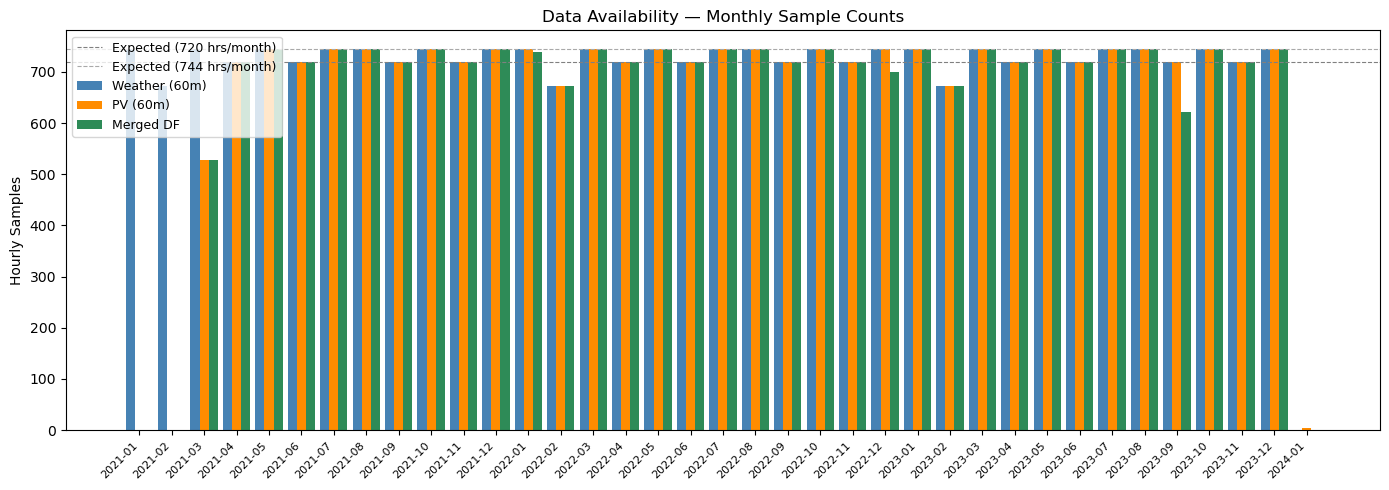

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

weather_60m['year_month'] = weather_60m.index.to_period('M')
pv_data_60m['year_month'] = pv_data_60m.index.to_period('M')
df['year_month']           = df.index.to_period('M')

weather_monthly = weather_60m.groupby('year_month').size()
pv_monthly      = pv_data_60m.groupby('year_month').size()
df_monthly      = df.groupby('year_month').size()

months     = sorted(set(weather_monthly.index) | set(pv_monthly.index) | set(df_monthly.index))
month_strs = [str(m) for m in months]
x = np.arange(len(months))
w = 0.28

ax.bar(x - w, [weather_monthly.get(m, 0) for m in months], width=w, label='Weather (60m)', color='steelblue')
ax.bar(x,     [pv_monthly.get(m, 0)      for m in months], width=w, label='PV (60m)',      color='darkorange')
ax.bar(x + w, [df_monthly.get(m, 0)      for m in months], width=w, label='Merged DF',     color='seagreen')
ax.axhline(720, color='grey', linestyle='--', linewidth=0.8, label='Expected (720 hrs/month)')
ax.axhline(744, color='darkgrey', linestyle='--', linewidth=0.8, label='Expected (744 hrs/month)')
ax.set_xticks(x)
ax.set_xticklabels(month_strs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Hourly Samples")
ax.set_title("Data Availability — Monthly Sample Counts")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Stage 1: Per-building LSTM(s) Using Weather and Power Data
---
This section trains and compares a standard LSTM and a VMD-LSTM Ensemble, both using lagged PV output and weather features as inputs. Models are trained on a single station, selected in the first cell of this section.

Each model accepts a sliding window of `lookback` timesteps and outputs a multi-step forecast of `horizon` steps ahead — i.e. for horizon=6, the model simultaneously predicts $\hat{y}_{t+1}, \hat{y}_{t+2}, ... , \hat{y}_{t+6}$.

## Feature engineering

#### Selecting Station
Here we choose the station we wish to investigate, and drop its PV column NaNs. Only wanted columns (i.e `weather_features` and the station's PV) are kept before progressing.

In [10]:
power_column = 'SQ19' #data starts earliest

# Filter out rows where SQ19 is NaN
df_lstm = df[df[power_column].notna()].copy()

# Drop all columns except Time, weather features, and power columns
cols_to_keep = weather_features + [power_column]
df_lstm = df_lstm[cols_to_keep]
df_lstm[power_column] = np.clip(df_lstm[power_column], 0, None)
print(f"Rows after removing SQ19 NaN: {len(df_lstm)}")
print(f"SQ19 NaN remaining: {df['SQ19'].isna().sum()}")

Rows after removing SQ19 NaN: 24029
SQ19 NaN remaining: 472


#### Investigating Time Entries
The time index of the selected station is investigated to quantify any remaining time gaps: their count, size distribution, and fraction of total timesteps. This serves as a data-validation step.

Prompt to Perplexity Research: *"I have df_lstm, a DataFrame with a DatetimeIndex at 60-minute resolution that I've preprocessed for LSTM training. Before training, I want to run a gap analysis on the time index to check for irregularities. Please: (1) count the number of gaps larger than one timestep, (2) print summary statistics of the gap sizes in minutes (mean, median, 95th percentile, and max), (3) print the fraction of timesteps that are gaps, and (4) plot a histogram of the gap size distribution."*

Number of gaps: 60
Gap stats (min):
  Mean: 11.1
  Median: 11.0
  95th: 11.0
  Max: 99.0
Gap fraction: 0.2%


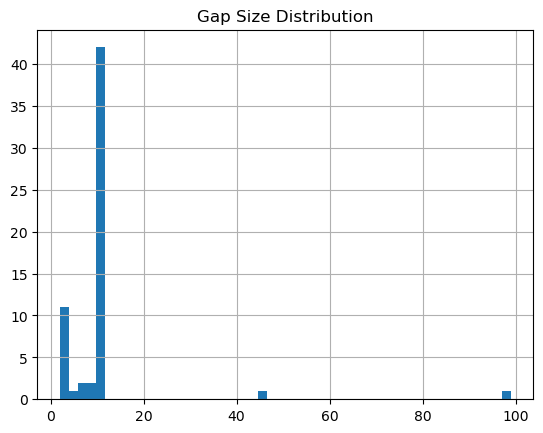

In [11]:
# Gap analysis
deltas = df_lstm.index.to_series().diff().dropna()

# 1. NUMBER OF GAPS (> base step)
gaps = deltas > pd.Timedelta(minutes=60)
num_gaps = gaps.sum()
print(f"Number of gaps: {num_gaps}")

# 2. GAP STATISTICS
gap_sizes_min = deltas[gaps].dt.total_seconds() / 3600
print(f"Gap stats (min):")
print(f"  Mean: {gap_sizes_min.mean():.1f}")
print(f"  Median: {gap_sizes_min.median():.1f}")
print(f"  95th: {gap_sizes_min.quantile(0.95):.1f}")
print(f"  Max: {gap_sizes_min.max():.1f}")
print(f"Gap fraction: {num_gaps/len(deltas):.1%}")

# 3. VISUAL
gap_sizes_min.hist(bins=50)
plt.title('Gap Size Distribution')
plt.show()

#### Cyclically Encoding Time
Hour-of-day and day-of-year are encoded as sine/cosine pairs onto a unit circle, allowing the model to learn the continuity of periodic time features (e.g. that 23:00 and 00:00 are adjacent). This was developed, but not used in the final LSTMs due to being too correlated to the solar position encoding below.

In [12]:
# Hour (0-23): Map to unit circle
df_lstm['hour_sin'] = np.sin(2 * np.pi * df_lstm.index.hour / 24)
df_lstm['hour_cos'] = np.cos(2 * np.pi * df_lstm.index.hour / 24)

# Day of year (1-365): Map to unit circle
df_lstm['doy_sin'] = np.sin(2 * np.pi * df_lstm.index.dayofyear / 365)
df_lstm['doy_cos'] = np.cos(2 * np.pi * df_lstm.index.dayofyear / 365)

#### Cyclically Encoding Solar Position 
Solar zenith and azimuth are computed for each timestep using pvlib and cyclically encoded. This directly informs the model of the sun's physical position, capturing seasonal and diurnal generation patterns that may not be fully recoverable from time encodings alone. Approximate coordinates for Hong Kong (`latitude=22.3, longitude=114.2, altitude=50`) are used, as precise station locations are unavailable and further precision is unnecessary.

In [13]:
# Hong Kong central coordinates (covers most panels across territory)
hk_central = pvlib.location.Location(
    latitude=22.3, 
    longitude=114.2, 
    tz='Asia/Hong_Kong',  # or 'UTC+8'
    altitude=50  # conservative avg
)
# Compute solar position for your df timestamps
solar_position = hk_central.get_solarposition(df_lstm.index)

# Add to dataframe (drop elevation if you want, keep key angles)
df_lstm['zenith'] = solar_position['apparent_zenith']   # 0deg overhead → 90deg horizon → 180deg night
df_lstm['azimuth'] = solar_position['azimuth']          # 0deg N → 90deg E → 180deg S → 270deg W

print("SZA sample:")
print(df_lstm[['zenith', 'azimuth']].head(10).round(1))
print(f"\nNight stats (zenith>95°): {len(df_lstm[df_lstm.zenith > 95])} / {len(df_lstm)} rows ({100*len(df_lstm[df_lstm.zenith > 95])/len(df_lstm):.1f}%)")

SZA sample:
                     zenith  azimuth
Time                                
2021-03-10 00:00:00    71.7    102.5
2021-03-10 01:00:00    58.4    110.0
2021-03-10 02:00:00    45.8    120.3
2021-03-10 03:00:00    34.9    136.2
2021-03-10 04:00:00    27.6    161.7
2021-03-10 05:00:00    27.1    194.6
2021-03-10 06:00:00    33.7    221.4
2021-03-10 07:00:00    44.4    238.3
2021-03-10 08:00:00    56.8    249.1
2021-03-10 10:00:00    83.7    263.1

Night stats (zenith>95°): 11005 / 24029 rows (45.8%)


In [14]:
# Zenith (0-180deg → period=360 for full circle continuity at sunrise/sunset)
df_lstm['zenith_sin'] = np.sin(2 * np.pi * df_lstm['zenith'] / 360)
df_lstm['zenith_cos'] = np.cos(2 * np.pi * df_lstm['zenith'] / 360)

# Azimuth (0-360deg → period=360 standard)
df_lstm['azimuth_sin'] = np.sin(2 * np.pi * df_lstm['azimuth'] / 360)
df_lstm['azimuth_cos'] = np.cos(2 * np.pi * df_lstm['azimuth'] / 360)

# Drop raw angles (redundant)
df_lstm.drop(columns=['zenith', 'azimuth'], inplace=True)

In [15]:
df_lstm.head()

,irradiance,relative_humidity,temperature,SQ19,hour_sin,hour_cos,doy_sin,doy_cos,zenith_sin,zenith_cos,azimuth_sin,azimuth_cos
Time,,,,,,,,,,,,
2021-03-10 00:00:00,4.639122,76.729933,17.641750,0.0,0.000000,1.000000,0.927542,0.37372,0.949554,0.313603,0.976276,-0.216528
2021-03-10 01:00:00,4.673955,76.763667,17.574400,0.0,0.258819,0.965926,0.927542,0.37372,0.851838,0.523805,0.939560,-0.342384
2021-03-10 02:00:00,4.833763,79.332767,17.494717,0.0,0.500000,0.866025,0.927542,0.37372,0.717339,0.696724,0.863064,-0.505095
2021-03-10 03:00:00,4.716148,76.912300,17.541183,0.0,0.707107,0.707107,0.927542,0.37372,0.571768,0.820415,0.691973,-0.721923
2021-03-10 04:00:00,4.651888,73.599467,17.446050,0.0,0.866025,0.500000,0.927542,0.37372,0.462905,0.886408,0.313677,-0.949530


#### Splitting Data
We perform a temporal train-validation-test split (70%-15%-15%) to preserve temporal ordering and avoid data leakage in time-series forecasting.

In [16]:
train_size = int(len(df_lstm) * 0.7)
val_size = int(len(df_lstm) * 0.15)

train = df_lstm[:train_size]
val = df_lstm[train_size:train_size+val_size]
test = df_lstm[train_size+val_size:]

#### Finding the IMFs using VMD
---
This section applies Variational Mode Decomposition (VMD) to the dataset (for use on the VMD-LSTM Ensemble). VMD decomposes signals into K smooth frequency components (called Intrinsic Mode Functions / IMFs) and a residual. <br>

##### Defining the VMD function
This function was edited by Perplexity Research after the following prompt: *"I'm using Variational Mode Decomposition to decompose my power signal before feeding into an LSTM. The function vmd_power() sometimes returns an array with length mismatch to input. Please edit the function to guarrantee length match."*

In [17]:
def vmd_power_exact(power_raw_imp, alpha, K, tol=1e-6):
    """VMD w/ guaranteed exact length match."""
    orig_len = len(power_raw_imp)
    u, _, _ = VMD(power_raw_imp, alpha, 0, K, False, 1, tol)
    
    # Pad/truncate to exact original length
    if u.shape[1] < orig_len:
        # Rare pad (unlikely)
        pad_width = orig_len - u.shape[1]
        u = np.pad(u, ((0,0),(0,pad_width)), mode='edge')
    elif u.shape[1] > orig_len:
        # Common truncate
        u = u[:, :orig_len]
    assert u.shape[1] == orig_len, f"VMD length mismatch: {u.shape[1]} != {orig_len}"
    return u

##### Imputing Power for Constant Time Gaps
VMD requires evenly-spaced timesteps, so gaps in the PV time series must be filled before decomposition. Approximately 0.2% of the total modelled timeframe contains gaps, with the majority under 12 hours. Linear interpolation is applied to fill these gaps, which is well-established as the recommended approach for short gaps in hourly solar data. Given that 99.8% of values are genuine measurements, the interpolated samples represent a negligible fraction of the dataset and should not meaningfully distort the resulting IMFs. In datasets with higher gap rates, this approach may not be viable. Interpolated values coinciding with sub-horizon solar angles ($\cos\theta < 0$) were clamped to zero, as linear interpolation across night-time gaps would otherwise produce physically impossible non-zero power estimates.
Since the VMD is performed separately on the train, val, and test sets to prevent data leakage, the imputation was separated as well.

In [18]:
def prepare_power_vmd(df_slice, power_col, step_mins, zenith_col='zenith_cos'):
    df_slice = df_slice.sort_index()

    if not df_slice.index.is_unique:
        raise ValueError("Duplicate timestamps found in df_slice.index")

    start_time = df_slice.index.min()
    end_time = df_slice.index.max()
    full_index = pd.date_range(start_time, end_time, freq=f"{step_mins}min")

    power_reindexed = df_slice[power_col].reindex(full_index)
    zenith_reindexed = df_slice[zenith_col].reindex(full_index)

    power_filled = (
        power_reindexed
        .interpolate(method='time', limit_area='inside')
        .ffill()
        .bfill()
    )

    zenith_filled = (
        zenith_reindexed
        .interpolate(method='time', limit_area='inside')
        .ffill()
        .bfill()
    )

    original_mask = full_index.isin(df_slice.index)
    inserted_mask = ~original_mask

    clamp_mask = inserted_mask & (zenith_filled.to_numpy() < 0)

    power_vmd = power_filled.to_numpy().copy()
    power_vmd[clamp_mask] = 0.0

    orig_indices = full_index.get_indexer(df_slice.index)
    if np.any(orig_indices < 0):
        missing = df_slice.index[orig_indices < 0]
        raise ValueError(f"Some original timestamps not found in full_index: {missing[:5]}")

    assert np.array_equal(full_index[orig_indices], df_slice.index)

    return power_vmd, original_mask, full_index



# Usage
train_power_imp, train_orig_idx, train_vmd_times = prepare_power_vmd(train, power_column, 60)
val_power_imp, val_orig_idx, val_vmd_times = prepare_power_vmd(val, power_column, 60)
test_power_imp, test_orig_idx, test_vmd_times = prepare_power_vmd(test, power_column, 60)

# #Log transform power for better IMFs
# train_power_log = np.log1p(train_power_imp)
# val_power_log = np.log1p(val_power_imp) 
# test_power_log = np.log1p(test_power_imp)

##### Genetic Algorithm to Optimise $K$ and $\alpha$ for VMD
---
The Genetic Algorithm is an optimisation method used to search for an optimal set of parameters. The usage of this is inspired by the paper referenced below. It evolves a population of candidate solutions over generations, mimicking natural selection. It is mathematically defined below, and the functions used are defined.<br>
https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2023SW003552 <br> 

**1. Population Initialisation** <br>
Randomly sample `pop_size` candidates from $K\in [K_{min},K_{max}]$, $\alpha\in [\alpha_{min},\alpha_{max}]$: <br>
> $K_i \sim \text{Uniform}(K_{min},K_{max}), \: \alpha_i \sim \text{Uniform}(\alpha_{min},\alpha_{max})$

**2. Fitness Function (Envelope Entropy)**<br>
For each candidate pair $(K, \alpha)$, run VMD and then compute average IMF envelope entropy. This is defined as:
> $E_p = −\sum_i[\epsilon(i)\ln(\epsilon(i))]\: \: \text{where} \: \: \epsilon(i) = \frac{a(i)}{\sum_i a(i)}$ 

> $a(i) = |\mathcal{H}\{ \text{IMF}_k(i) \}  |$

> $ \text{fitness}(K, \alpha) = \text{mean}(Ep_k) \: \: \text{for} \: \: k=1 \: \: \text{to}\: \: K$

**3. Tournament Selection** <br>
Pick `tournament_size=3` random candidates, choose best (minimise fitness).<br>

**4. Crossover** <br>
Mix parents with `crossover_prob = 0.9`.
> $\alpha_\text{child1} = \lambda \alpha_\text{parent1} + (1-\lambda)\alpha_\text{parent2}$

> $K_\text{child1} = \text{round}(\frac{K_\text{parent1} + K_\text{parent2}}{2}) $

**5. Mutation**<br>
Randomly tweak $K$ or $\alpha$ with probability `mutation_prob = 0.1`.
>$K' \sim \text{Uniform}(K_\text{min}, K_\text{max})$

> $\alpha' = \alpha + \mathcal{N}(0, 0.1\times \alpha_\text{range})$

**Repeat steps 3-5 until convergence.**

In [19]:
# =========================================================
# 1) Envelope entropy fitness (paper-style)
# =========================================================

def envelope_entropy_1d(x, eps=1e-12):
    """
    Envelope entropy for a single 1D signal.
    Ep = -sum(p_i * log(p_i)), where p_i is the normalized envelope.
    """
    x = np.asarray(x, dtype=float)
    analytic = hilbert(x)
    envelope = np.abs(analytic)

    s = envelope.sum()
    if not np.isfinite(s) or s <= eps:
        return np.inf

    p = envelope / (s + eps)
    p = np.clip(p, eps, None)
    return -np.sum(p * np.log(p))


def vmd_fitness_envelope_entropy(signal, alpha, K):
    """
    One scalar fitness for GA.
    We decompose the signal and average envelope entropy across IMFs.
    Lower is better.
    """
    K = int(round(K))
    K = max(2, min(10, K))
    alpha = float(alpha)
    alpha = max(1.0, min(5000.0, alpha))

    try:
        imfs = vmd_power_exact(signal, alpha=alpha, K=K)
        entropies = [envelope_entropy_1d(imfs[i]) for i in range(imfs.shape[0])]
        fit = float(np.mean(entropies))
        if not np.isfinite(fit):
            return np.inf
        return fit
    except Exception:
        return np.inf


# =========================================================
# 2) Optional diagnostics for the winning candidate
# =========================================================

def vmd_diagnostics(signal, alpha, K):
    imfs = vmd_power_exact(signal, alpha=alpha, K=K)
    recon = imfs.sum(axis=0)
    resid = signal - recon

    sse = np.sum((signal - recon) ** 2)
    sst = np.sum((signal - np.mean(signal)) ** 2)
    recon_r2 = 1.0 - sse / sst if sst > 0 else np.nan

    resid_rmse = float(np.sqrt(np.mean(resid ** 2)))
    resid_var_ratio = float(np.var(resid) / (np.var(signal) + 1e-12))

    return {
        "imfs": imfs,
        "recon": recon,
        "resid": resid,
        "recon_r2": recon_r2,
        "resid_rmse": resid_rmse,
        "resid_var_ratio": resid_var_ratio,
    }


# =========================================================
# 3) GA components
# =========================================================

def init_population(pop_size, K_bounds=(2, 10), alpha_bounds=(0, 5000), seed=42):
    rng = np.random.default_rng(seed)
    pop = []
    for _ in range(pop_size):
        K = rng.integers(K_bounds[0], K_bounds[1] + 1)
        alpha = rng.uniform(alpha_bounds[0], alpha_bounds[1])
        pop.append([float(K), float(alpha)])
    return np.array(pop, dtype=float)


def tournament_select(population, fitnesses, tournament_size=3, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    idx = rng.choice(len(population), size=tournament_size, replace=False)
    best_idx = idx[np.argmin(fitnesses[idx])]
    return population[best_idx].copy()


def crossover(parent1, parent2, crossover_prob=0.9, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    c1, c2 = parent1.copy(), parent2.copy()

    if rng.random() < crossover_prob:
        # Arithmetic crossover for alpha, swap-or-average for K
        lam = rng.random()
        c1[1] = lam * parent1[1] + (1 - lam) * parent2[1]
        c2[1] = (1 - lam) * parent1[1] + lam * parent2[1]

        if rng.random() < 0.5:
            c1[0], c2[0] = parent2[0], parent1[0]
        else:
            avgK = round((parent1[0] + parent2[0]) / 2.0)
            c1[0], c2[0] = avgK, avgK

    return c1, c2


def mutate(individual, mutation_prob=0.1, K_bounds=(2, 10), alpha_bounds=(0, 5000), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    child = individual.copy()

    if rng.random() < mutation_prob:
        child[0] = rng.integers(K_bounds[0], K_bounds[1] + 1)

    if rng.random() < mutation_prob:
        alpha_span = alpha_bounds[1] - alpha_bounds[0]
        child[1] += rng.normal(0, 0.10 * alpha_span)

    child[0] = float(int(np.clip(round(child[0]), K_bounds[0], K_bounds[1])))
    child[1] = float(np.clip(child[1], alpha_bounds[0], alpha_bounds[1]))

    return child


# =========================================================
# 4) Main GA
# =========================================================

def ga_optimize_vmd(
    train_signal,
    pop_size=30,
    n_generations=50,
    crossover_prob=0.9,
    mutation_prob=0.1,
    K_bounds=(2, 10),
    alpha_bounds=(0, 5000),
    elite_size=2,
    tournament_size=3,
    seed=42,
    show_individuals=True,  # NEW: per-individual progress
    patience = 10
):
    rng = np.random.default_rng(seed)
    population = init_population(pop_size, K_bounds, alpha_bounds, seed)

    history = []
    best_solution = None
    best_fitness = np.inf
    stagnant_count = 0
    
    print(f"GA START: {pop_size} pop, {n_generations} gens, signal len={len(train_signal)}")
    print("-" * 60)

    for gen in range(n_generations):
        print(f"\n=== [Gen {gen+1:02d}/{n_generations}] ===")

        # Fitness evaluation with progress
        fitnesses = []
        for i, ind in enumerate(population):
            if show_individuals and i % 10 == 0:
                print(f"  Eval {i+1:2d}/{pop_size} K={int(round(ind[0]))} alpha={ind[1]:.0f}...", end=" ")
            
            fit = vmd_fitness_envelope_entropy(train_signal, ind[1], ind[0])
            fitnesses.append(fit)
            
            if show_individuals and i % 5 == 0:
                print(f"fit={fit:.4f}")

        fitnesses = np.array(fitnesses, dtype=float)
        
        # Sort and update best
        order = np.argsort(fitnesses)
        population = population[order]
        fitnesses = fitnesses[order]

        if fitnesses[0] < best_fitness:
            best_fitness = fitnesses[0]
            best_solution = population[0].copy()
            stagnant_count = 0
        else:
            stagnant_count += 1
            
        # EARLY STOP
        if stagnant_count >= patience:
            print(f"\nEARLY STOP: No improvement for {patience} gens")
            print(f"Final best: fit={best_fitness:.6f}")
            break
            
        history.append({
            "generation": gen + 1,
            "best_fitness": float(fitnesses[0]),
            "best_K": int(round(population[0][0])),
            "best_alpha": float(population[0][1]),
            "mean_fitness": float(np.mean(fitnesses[np.isfinite(fitnesses)]))
        })

        print(f"  [Gen {gen+1}] Best: fit={fitnesses[0]:.6f} K={int(round(population[0][0]))} alpha={population[0][1]:.1f}")
        print(f"  Mean fitness: {np.mean(fitnesses[np.isfinite(fitnesses)]):.6f} | Finite: {np.sum(np.isfinite(fitnesses))}/{pop_size}")
            
        # Evolution step (no print needed, it's fast)
        next_population = []
        for i in range(elite_size):
            next_population.append(population[i].copy())

        while len(next_population) < pop_size:
            p1 = tournament_select(population, fitnesses, tournament_size, rng)
            p2 = tournament_select(population, fitnesses, tournament_size, rng)
            c1, c2 = crossover(p1, p2, crossover_prob, rng)
            c1 = mutate(c1, mutation_prob, K_bounds, alpha_bounds, rng)
            c2 = mutate(c2, mutation_prob, K_bounds, alpha_bounds, rng)
            next_population.append(c1)
            if len(next_population) < pop_size:
                next_population.append(c2)

        population = np.array(next_population, dtype=float)

    print("\n" + "=" * 60)
    print("GA COMPLETE")
    print(f"Best: K={best_solution[0]:.1f} alpha={best_solution[1]:.1f} fitness={best_fitness:.6f}")

    return {
        "best_K": int(round(best_solution[0])),
        "best_alpha": float(best_solution[1]),
        "best_fitness": float(best_fitness),
        "history": pd.DataFrame(history)
    }

##### Running GA on Train data only
This is limited to training data in order to prevent data leakage.

In [ ]:
ga_result = ga_optimize_vmd(
    train_signal=train_power_imp,
    pop_size=30,
    n_generations=50,
    crossover_prob=0.9,
    mutation_prob=0.1,
    K_bounds=(2, 8),
    alpha_bounds=(100, 3000),
    elite_size=2,
    tournament_size=3,
    seed=10,
)
print(ga_result)
best_K = ga_result["best_K"]
best_alpha = ga_result["best_alpha"]

##### Performing Variational Mode Decomposition
The power signal is then decomposed using VMD into `best_K` IMFs, as found by the GA. A recon $r^2$ is used to check how well these IMFs represent the data. Lastly, a residual mode is added such that the sum: (IMFs + residual = imputed PV) for each timestep. This means the VMD Ensemble will have K+1 modes to model.

In [20]:
best_alpha, best_K = 100.0 , 7 #saved for SQ19 - avoid repeating lengthy GA compute

In [21]:
train_imfs_raw = vmd_power_exact(train_power_imp, best_alpha, best_K)
val_imfs_raw = vmd_power_exact(val_power_imp, best_alpha, best_K)
test_imfs_raw = vmd_power_exact(test_power_imp, best_alpha, best_K)

# Recon check
train_recon_raw = train_imfs_raw.sum(axis=0)
reconr2 = r2_score(train_power_imp, train_recon_raw)
print(f"Recon R²: {reconr2:.4f}")

Recon R²: 0.9998


In [22]:
# Append residuals as extra "IMF" at index -1
train_imfs_raw = np.vstack([train_imfs_raw, train_power_imp - train_imfs_raw.sum(axis=0)])
val_imfs_raw   = np.vstack([val_imfs_raw,   val_power_imp   - val_imfs_raw.sum(axis=0)])   
test_imfs_raw  = np.vstack([test_imfs_raw,   test_power_imp  - test_imfs_raw.sum(axis=0)])

print(f"train_imfs_raw shape: {train_imfs_raw.shape}")  # (5, 17185)
print(f"IMFs 0-{best_K-1}: components, IMF {best_K}: residual")

# Verify perfect reconstruction
train_recon_check = train_imfs_raw.sum(axis=0)
print(f"Recon R² with residual: {r2_score(train_power_imp, train_recon_check):.4f}")  # Should be ~1.0000

train_imfs_raw shape: (8, 17186)
IMFs 0-6: components, IMF 7: residual
Recon R² with residual: 1.0000


##### Aligning IMFs back with data cols
After VMD was performed on the imputed, gap-filled signal, the resulting IMF arrays were mapped back to the original observed timestamps using the saved index arrays from each split. This ensures that only genuine measurements are retained for model training, validation, and testing, while imputed rows are removed before sequence construction.

In [23]:
# **Slice using saved indices**
train_imfs_obs = train_imfs_raw[:, train_orig_idx]
val_imfs_obs = val_imfs_raw[:, val_orig_idx]
test_imfs_obs = test_imfs_raw[:, test_orig_idx]

print(f"IMFs final: train {train_imfs_obs.shape}")

IMFs final: train (8, 16820)


In [24]:
# Full exact check
assert np.array_equal(train_vmd_times[train_orig_idx], train.index)

print("Recovered originals exactly:",
      np.array_equal(train_vmd_times[train_orig_idx], train.index))

print("IMFs sliced:", train_imfs_obs.shape, "matches train:", len(train))

Recovered originals exactly: True
IMFs sliced: (8, 16820) matches train: 16820


#### Scaling Data
The desired engineered columns to the model are selected with `weather_features_engineered`. As mentioned above, the solar encoding is adding to the input features, whilst the cyclical encoding of time was disincluded for the final product due to its correlation with solar encoding.

We then normalise features using separate scalers: one `MinMaxScaler` fitted on training weather features (then applied identically to val/test), and one `MinMaxScaler` for the power output (for standard LSTM), or per IMF for power outputs (for VMD LSTM Ensemble). These are fitted on training set, then applied identically to val/test. 

In [25]:
weather_features_engineered = weather_features + [#'hour_sin', 
                                                  #'hour_cos', 
                                                  #'doy_sin', 
                                                  #'doy_cos',
                                                  'zenith_sin',
                                                  'zenith_cos',
                                                  'azimuth_sin',
                                                  'azimuth_cos'
                                                 ]

dynamic_features = weather_features_engineered + ['power_input']

# Normalize weather features (one scaler for all)
weather_scaler = MinMaxScaler()
train_weather_scaled = weather_scaler.fit_transform(train[weather_features_engineered])
val_weather_scaled = weather_scaler.transform(val[weather_features_engineered])
test_weather_scaled = weather_scaler.transform(test[weather_features_engineered])

# Normalize power output for LSTM
power_scaler = MinMaxScaler()
train_power_scaled = power_scaler.fit_transform(train[power_column].values.reshape(-1, 1)).flatten()
val_power_scaled = power_scaler.transform(val[power_column].values.reshape(-1, 1)).flatten()
test_power_scaled = power_scaler.transform(test[power_column].values.reshape(-1, 1)).flatten()

# IMF scaling (per K) for VMD LSTMs
imf_scalers = []
train_imf_scaled = np.zeros((best_K+1, len(train)))
val_imf_scaled = np.zeros((best_K+1, len(val)))
test_imf_scaled = np.zeros((best_K+1, len(test)))

for k in range(best_K+1):
    print(f"Scaling IMF {k+1}/{best_K+1}...")
    scaler_k = MinMaxScaler()
    
    # Fit on train IMF_k, transform all
    train_k_scaled = scaler_k.fit_transform(train_imfs_obs[k].reshape(-1, 1)).flatten()
    val_k_scaled = scaler_k.transform(val_imfs_obs[k].reshape(-1, 1)).flatten()
    test_k_scaled = scaler_k.transform(test_imfs_obs[k].reshape(-1, 1)).flatten()
    
    train_imf_scaled[k] = train_k_scaled
    val_imf_scaled[k] = val_k_scaled
    test_imf_scaled[k] = test_k_scaled
    imf_scalers.append(scaler_k)

print("IMF scaling complete!")

Scaling IMF 1/8...
Scaling IMF 2/8...
Scaling IMF 3/8...
Scaling IMF 4/8...
Scaling IMF 5/8...
Scaling IMF 6/8...
Scaling IMF 7/8...
Scaling IMF 8/8...
IMF scaling complete!


#### Data Sequencing 
Finally, we create sequences with an adjustable lookback/lookahead window. These are selected using the `lookback` and `horizon` variables.

`create_sequences` is generated by Claude Sonnet 4.6 thinking. Prompt: *"Write a function to create LSTM input sequences from my weather features and power targets. It should take a lookback window and a forecast horizon, and skip any window that contains a gap in the timestamps (non-contiguous 60-minute steps). The input X should concatenate the weather features with the lagged power values, and y should be the multi-step forecast target. Return X with shape (N, lookback, features) and y with shape (N, horizon)."*

In [26]:
def create_sequences(weather_data, y_data, timestamps, lookback, horizon, step_mins=60):
    X, y = [], []
    expected_gap = pd.Timedelta(minutes=step_mins)

    for i in range(len(weather_data) - lookback - horizon + 1):  # +1 to avoid off-by-one
        # Check full window: lookback + horizon steps must all be contiguous
        window_timestamps = timestamps[i : i + lookback + horizon]
        diffs = np.diff(window_timestamps)

        if not all(d == expected_gap for d in diffs):
            continue

        weather_seq = weather_data[i : i + lookback]
        y_slice     = y_data[i : i + lookback]
        y_seq       = y_slice.reshape(-1, 1) if y_slice.ndim == 1 else y_slice[:, [0]]

        X.append(np.concatenate([weather_seq, y_seq], axis=-1))
        y.append(y_data[i + lookback : i + lookback + horizon])   # shape: (horizon,)

    return np.array(X), np.array(y)  # X: (N, lookback, features), y: (N, horizon)



# Lookback params
lookback_steps = 48
horizon = 24

#Create sequences for standard LSTM 
print("Creating standard LSTM sequence...")
standard_X_train, standard_y_train = create_sequences(train_weather_scaled, train_power_scaled, train.index.to_numpy(), lookback_steps,horizon)
standard_X_val, standard_y_val = create_sequences(val_weather_scaled, val_power_scaled, val.index.to_numpy(), lookback_steps,horizon)
standard_X_test, standard_y_test = create_sequences(test_weather_scaled, test_power_scaled, test.index.to_numpy(),  lookback_steps,horizon)
print(f"Sequences ready for standard LSTM. Train dimensions are {standard_X_train.shape, standard_y_train.shape}")
# Create sequences for ALL K VMD-LSTM models
imf_X_train_list = []
imf_y_train_list = []
imf_X_val_list = []
imf_y_val_list = []
imf_X_test_list = []
imf_y_test_list = []

print("Creating VMD-LSTM Ensemble sequences...")
for k in range(best_K+1):
    print(f"IMF {k+1}/{best_K+1}...")
    
    # Train
    X_train_k, y_train_k = create_sequences(train_weather_scaled, train_imf_scaled[k], train.index.to_numpy(), lookback_steps,horizon)
    imf_X_train_list.append(X_train_k)
    imf_y_train_list.append(y_train_k)
    
    # Val  
    X_val_k, y_val_k = create_sequences(val_weather_scaled, val_imf_scaled[k], val.index.to_numpy(), lookback_steps,horizon)
    imf_X_val_list.append(X_val_k)
    imf_y_val_list.append(y_val_k)
    
    # Test
    X_test_k, y_test_k = create_sequences(test_weather_scaled, test_imf_scaled[k], test.index.to_numpy(), lookback_steps,horizon)
    imf_X_test_list.append(X_test_k)
    imf_y_test_list.append(y_test_k)

print(f"Sequences ready: X_train shapes {[(x.shape, y.shape) for x,y in zip(imf_X_train_list, imf_y_train_list)]}")


Creating standard LSTM sequence...
Sequences ready for standard LSTM. Train dimensions are ((15011, 48, 8), (15011, 24))
Creating VMD-LSTM Ensemble sequences...
IMF 1/8...
IMF 2/8...
IMF 3/8...
IMF 4/8...
IMF 5/8...
IMF 6/8...
IMF 7/8...
IMF 8/8...
Sequences ready: X_train shapes [((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24)), ((15011, 48, 8), (15011, 24))]


In [27]:
# Check first IMF sequences
print(f"IMF 0 - X_train: {imf_X_train_list[0].shape}")  
print(f"IMF 0 - y_train: {imf_y_train_list[0].shape}")
print(f"IMF 0 - X_val: {imf_X_val_list[0].shape}")

# Verify all identical X shapes
x_train_shapes = [x.shape for x in imf_X_train_list]
print(f"All X_train shapes identical: {len(set(x_train_shapes)) == 1}")

# Sample sizes
print(f"n_train_samples: {imf_X_train_list[0].shape[0]}")
print(f"lookback steps: {imf_X_train_list[0].shape[1]}")
print(f"n_weather_features: {imf_X_train_list[0].shape[2]}")


IMF 0 - X_train: (15011, 48, 8)
IMF 0 - y_train: (15011, 24)
IMF 0 - X_val: (3074, 48, 8)
All X_train shapes identical: True
n_train_samples: 15011
lookback steps: 48
n_weather_features: 8


#### Converting Data into Tensors + DataLoaders
This was done using a `batch_size` of 64.

In [28]:
batch_size = 64

#Standard LSTM
standard_train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_train),
    torch.FloatTensor(standard_y_train)
)

standard_val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_val),
    torch.FloatTensor(standard_y_val)
)

standard_test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(standard_X_test),
    torch.FloatTensor(standard_y_test)
)
standard_train_loader = DataLoader(standard_train_dataset, batch_size=batch_size, shuffle=True)
standard_val_loader = DataLoader(standard_val_dataset, batch_size=batch_size, shuffle=False)
standard_test_loader = DataLoader(standard_test_dataset, batch_size=batch_size, shuffle=False)

# DataLoaders for each IMF in VMD-LSTM Ensemble
imf_train_loaders = []
imf_val_loaders = []
imf_test_loaders = []
for k in range(best_K+1):
    # Train loader
    imf_train_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_train_list[k]), 
        torch.FloatTensor(imf_y_train_list[k]))
    imf_train_loaders.append(DataLoader(imf_train_dataset, batch_size=batch_size, shuffle=True))
    
    # Val loader  
    imf_val_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_val_list[k]), 
        torch.FloatTensor(imf_y_val_list[k]))
    imf_val_loaders.append(DataLoader(imf_val_dataset, batch_size=batch_size, shuffle=False))

    # Test loader  
    imf_test_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(imf_X_test_list[k]), 
        torch.FloatTensor(imf_y_test_list[k]))
    imf_test_loaders.append(DataLoader(imf_test_dataset, batch_size=batch_size, shuffle=False))

#### IMF Data Quality Check
Once this is done we also check for bad data (inf, NaN) in the IMF ensemble. These checks were generated by Claude Sonnet 4.6. Prompt: *"Write a quick diagnostic that checks the first few IMFs and weather inputs for NaNs/infs after scaling, then checks the generated sequence arrays for each IMF, then pulls one batch from the first DataLoader to confirm shapes and ranges, and finally verifies all IMF branches have consistent shapes and target lengths. Print a clean success message at the end if everything passes.”

In [29]:
# === IMF ENSEMBLE DATA QUALITY CHECKS ===
print("=== 1. IMF Scaled Data (Before Sequences) ===")
for k in range(best_K+1):
    print(f"IMF {k}: train min/max/NaN/inf: "
          f"{train_imf_scaled[k].min():.2f}/{train_imf_scaled[k].max():.2f}/"
          f"{np.isnan(train_imf_scaled[k]).sum()}/{np.isinf(train_imf_scaled[k]).sum()}")

print(f"\nWeather train NaN/inf: {np.isnan(train_weather_scaled).sum()}/{np.isinf(train_weather_scaled).sum()}")

print("\n=== 2. Sequence Quality ===")
for k in range(best_K+1):
    print(f"IMF {k} - X_train NaN/inf/shape: "
          f"{np.isnan(imf_X_train_list[k]).sum()}/{np.isinf(imf_X_train_list[k]).sum()}/{imf_X_train_list[k].shape}")
    print(f"          y_train NaN/inf/shape: "
          f"{np.isnan(imf_y_train_list[k]).sum()}/{np.isinf(imf_y_train_list[k]).sum()}/{imf_y_train_list[k].shape}")
    print(f"          X range: {imf_X_train_list[k].min():.2f}/{imf_X_train_list[k].max():.2f}")
    print(f"          y range: {imf_y_train_list[k].min():.2f}/{imf_y_train_list[k].max():.2f}\n")

print("=== 3. DataLoader Sanity (First IMF) ===")
batch_x, batch_y = next(iter(imf_train_loaders[0]))
print(f"Batch shape: X{batch_x.shape} y{batch_y.shape}")
print(f"Batch NaN/inf: X{torch.isnan(batch_x).sum().item()} y{torch.isnan(batch_y).sum().item()}")
print(f"Batch range: X{batch_x.min().item():.2f}/{batch_x.max().item():.2f} y{batch_y.min().item():.2f}/{batch_y.max().item():.2f}")

print("\n=== 4. Ensemble Consistency ===")
x_shapes = [x.shape for x in imf_X_train_list]
print(f"All X_train shapes identical: {len(set(x_shapes)) == 1}")
print(f"All y_train lengths identical: {all(len(y) == len(imf_y_train_list[0]) for y in imf_y_train_list)}")

print("\n✓ ALL CLEAN - READY TO TRAIN!")

=== 1. IMF Scaled Data (Before Sequences) ===
IMF 0: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 1: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 2: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 3: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 4: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 5: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 6: train min/max/NaN/inf: 0.00/1.00/0/0
IMF 7: train min/max/NaN/inf: 0.00/1.00/0/0

Weather train NaN/inf: 0/0

=== 2. Sequence Quality ===
IMF 0 - X_train NaN/inf/shape: 0/0/(15011, 48, 8)
          y_train NaN/inf/shape: 0/0/(15011, 24)
          X range: 0.00/1.00
          y range: 0.01/1.00

IMF 1 - X_train NaN/inf/shape: 0/0/(15011, 48, 8)
          y_train NaN/inf/shape: 0/0/(15011, 24)
          X range: 0.00/1.00
          y range: 0.00/1.00

IMF 2 - X_train NaN/inf/shape: 0/0/(15011, 48, 8)
          y_train NaN/inf/shape: 0/0/(15011, 24)
          X range: 0.00/1.00
          y range: 0.00/1.00

IMF 3 - X_train NaN/inf/shape: 0/0/(15011, 48, 8)
          y_train NaN

## Train LSTM

#### Standard LSTM Training Loop

In [31]:
standard_input_size = standard_X_train.shape[-1]
standard_model = SolarLSTM(
    input_size=standard_input_size,
    hidden_size=64,
    num_layers=2,
    output_size=horizon,
    dropout=0.2
)
#Train
standard_trainer = LSTMTrainer(standard_model, learning_rate=0.001)
standard_history = standard_trainer.fit(standard_train_loader, standard_val_loader, epochs=200, patience=15)

CUDA available: True
Device selected: cuda
Model device after .to(): cuda:0
Starting training...
Device: cuda
Model parameters: 57,944
Training samples: 15011
Validation samples: 3074
------------------------------------------------------------
Epoch 1, Train: 0.021169, Val: 0.012361
Epoch 2, Train: 0.011434, Val: 0.012337
Epoch 3, Train: 0.010942, Val: 0.011925
Epoch 4, Train: 0.010677, Val: 0.011723
Epoch 5, Train: 0.010439, Val: 0.011973
Epoch 6, Train: 0.010281, Val: 0.011494
Epoch 7, Train: 0.010164, Val: 0.011110
Epoch 8, Train: 0.010099, Val: 0.011297
Epoch 9, Train: 0.009924, Val: 0.011897
Epoch 10, Train: 0.009830, Val: 0.011589
LR reduced: 1.000000e-03 -> 5.000000e-04
Epoch 11, Train: 0.009820, Val: 0.011148
Epoch 12, Train: 0.009557, Val: 0.011258
Epoch 13, Train: 0.009597, Val: 0.011184
Epoch 14, Train: 0.009535, Val: 0.011337
LR reduced: 5.000000e-04 -> 2.500000e-04
Epoch 15, Train: 0.009475, Val: 0.011298
Epoch 16, Train: 0.009380, Val: 0.011711
Epoch 17, Train: 0.009352,

#### GA-VMD-LSTM Ensemble Training Loop
This trains an LSTM for each power mode (K IMFs and a residual) in order to predict the station's summed PV.

In [32]:
# === VMD-LSTM ENSEMBLE TRAINING ===
models = []
histories = []

for k in range(best_K+1):
    print(f'\n=== Training IMF {k+1}/{best_K+1} ===')
    print(f"Data shape: X {imf_X_train_list[k].shape}, y {imf_y_train_list[k].shape}")
    
    # Your exact model
    input_size = imf_X_train_list[k].shape[-1]  #weather features
    model_k = SolarLSTM(
        input_size=input_size,
        hidden_size = 96 if k ==1 else (64 if k<=3 else 24),
        num_layers = 2 if k <= 3 else 1,
        output_size=horizon,
        dropout=0.2
    )
    
    # Your exact trainer
    trainer_k = LSTMTrainer(model_k, learning_rate=0.001)
    
    # Your exact fit
    history_k = trainer_k.fit(
        imf_train_loaders[k], 
        imf_val_loaders[k], 
        epochs=300 if k<=2 else 250, 
        patience=15
    )
    
    models.append(model_k)
    histories.append(history_k)
    
    # Best val loss
    print(f"IMF {k+1} best val MSE: {min(history_k['val_loss']):.6f}")
    
for k in range(best_K+1):
    best_mse = min(histories[k]['val_loss'])
    print(f"IMF {k+1:2d}: {best_mse:8.6f}")
print("\n🎉 VMD-LSTM ENSEMBLE FULLY TRAINED!")
torch.save({'models': models, 'imf_scalers': imf_scalers}, 'vmd_lstm_ensemble.pth')


=== Training IMF 1/8 ===
Data shape: X (15011, 48, 8), y (15011, 24)
CUDA available: True
Device selected: cuda
Model device after .to(): cuda:0
Starting training...
Device: cuda
Model parameters: 57,944
Training samples: 15011
Validation samples: 3074
------------------------------------------------------------
Epoch 1, Train: 0.041333, Val: 0.014316
Epoch 2, Train: 0.012696, Val: 0.013041
Epoch 3, Train: 0.010719, Val: 0.010859
Epoch 4, Train: 0.009423, Val: 0.010312
Epoch 5, Train: 0.008686, Val: 0.008973
Epoch 6, Train: 0.007910, Val: 0.008432
Epoch 7, Train: 0.007375, Val: 0.008171
Epoch 8, Train: 0.007068, Val: 0.007587
Epoch 9, Train: 0.006667, Val: 0.007575
Epoch 10, Train: 0.006437, Val: 0.007661
Epoch 11, Train: 0.006212, Val: 0.007106
Epoch 12, Train: 0.005984, Val: 0.007891
Epoch 13, Train: 0.005777, Val: 0.007363
Epoch 14, Train: 0.005594, Val: 0.007616
LR reduced: 1.000000e-03 -> 5.000000e-04
Epoch 15, Train: 0.005492, Val: 0.008469
Epoch 16, Train: 0.005118, Val: 0.0067

## Test LSTMs

#### Standard LSTM Test
Test code generated by Claude Sonnet 4.6 Thinking. 

Prompt: *"After training my standard LSTM (standard_trainer, standard_model), run a full test evaluation. Please get test MSE from the trainer's validate method, collect all predictions and actuals from standard_test_loader (expecting shape (N, horizon)), and denormalize both using power_scaler.inverse_transform (handles per-horizon reshaping). Next, print a formatted table of per-horizon (rows) RMSE/MAE/R2 (columns) with t+1 to t+horizon labels. The final row of this table should display aggregate metrics over the whole horizon. Finally, plot training/validation loss history from standard_history with a vertical line at the best validation epoch."*

Test Loss (MSE): 0.008197
Predictions shape: (3058, 24)
Actuals shape:     (3058, 24)

Horizon    RMSE         MAE          R²        
--------------------------------------------
t+1        788.4955     481.4887     0.9789    
t+2        1565.9688    807.2961     0.9167    
t+3        1994.9806    1037.9517    0.8650    
t+4        2204.8330    1160.4579    0.8357    
t+5        2319.5800    1239.6127    0.8188    
t+6        2407.2559    1288.6237    0.8056    
t+7        2470.7262    1331.2260    0.7958    
t+8        2507.8725    1372.6642    0.7900    
t+9        2522.4843    1395.7534    0.7874    
t+10       2524.2460    1387.7169    0.7870    
t+11       2520.2588    1384.7684    0.7877    
t+12       2513.1813    1380.1271    0.7889    
t+13       2506.7960    1351.9491    0.7899    
t+14       2503.0998    1367.8702    0.7906    
t+15       2508.0793    1364.9104    0.7898    
t+16       2511.8131    1366.4333    0.7892    
t+17       2506.1916    1352.6855    0.7901    
t+18

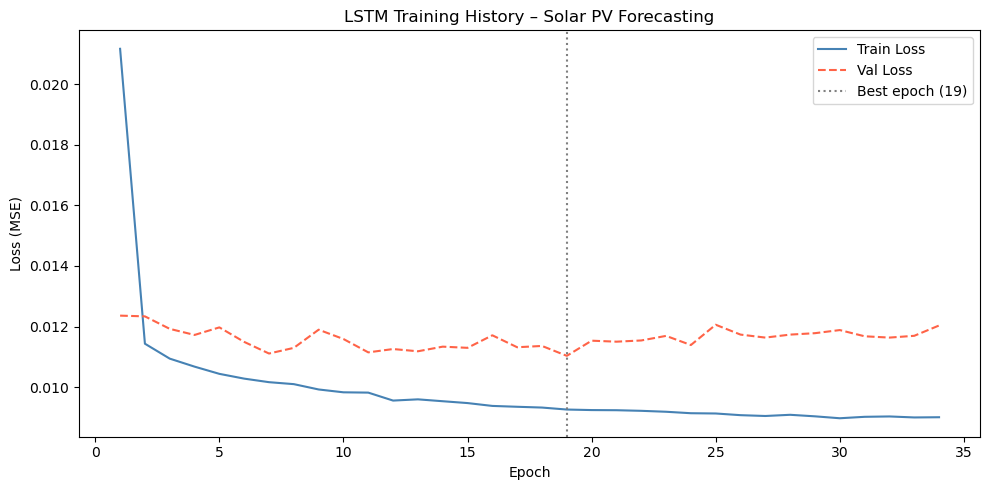

In [33]:
# Test loss
standard_test_loss = standard_trainer.validate(standard_test_loader)
print(f"Test Loss (MSE): {standard_test_loss:.6f}")

# Collect predictions
standard_model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for batch_x, batch_y in standard_test_loader:
        batch_x = batch_x.to(standard_trainer.device)
        predictions.append(standard_model(batch_x).cpu().numpy())
        actuals.append(batch_y.cpu().numpy())

predictions = np.concatenate(predictions, axis=0) 
actuals     = np.concatenate(actuals,     axis=0) 

print(f"Predictions shape: {predictions.shape}")
print(f"Actuals shape:     {actuals.shape}")

# Denormalize — inverse_transform expects (N, 1), so do it per horizon
predictions_denorm = np.stack([
    power_scaler.inverse_transform(predictions[:, h].reshape(-1, 1)).flatten()
    for h in range(horizon)
], axis=1)  

actuals_denorm = np.stack([
    power_scaler.inverse_transform(actuals[:, h].reshape(-1, 1)).flatten()
    for h in range(horizon)
], axis=1) 

# Per-step metrics
print(f"\n{'Horizon':<10} {'RMSE':<12} {'MAE':<12} {'R²':<10}")
print("-" * 44)
standard_r2_list=[]
for h in range(horizon):
    p, a  = predictions_denorm[:, h], actuals_denorm[:, h]
    rmse  = np.sqrt(mean_squared_error(a, p))
    mae   = mean_absolute_error(a, p)
    r2    = r2_score(a, p)
    standard_r2_list.append(r2)
    print(f"t+{h+1:<8} {rmse:<12.4f} {mae:<12.4f} {r2:<10.4f}")

# Aggregate metrics (flattened over all horizons)
print("-" * 44)
p_flat, a_flat = predictions_denorm.flatten(), actuals_denorm.flatten()
print(f"{'Overall':<10} {np.sqrt(mean_squared_error(a_flat, p_flat)):<12.4f} "
      f"{mean_absolute_error(a_flat, p_flat):<12.4f} {r2_score(a_flat, p_flat):<10.4f}")

train_loss = standard_history['train_loss']
val_loss   = standard_history['val_loss']
epochs     = range(1, len(train_loss) + 1)

# Find where early stopping fired (best val epoch)
best_epoch = val_loss.index(min(val_loss)) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_loss, label='Train Loss', color='steelblue')
ax.plot(epochs, val_loss,   label='Val Loss',   color='tomato', linestyle='--')
ax.axvline(x=best_epoch, color='grey', linestyle=':', label=f'Best epoch ({best_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('LSTM Training History – Solar PV Forecasting')
ax.legend()
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

#### GA-VMD-LSTM Ensemble Test
Test code generated by Claude Sonnet 4.6 Thinking.

Prompt: *"Complete evaluation for my VMD-LSTM ensemble. Sum denormalised IMF predictions (kth IMF scaler stored in imf_scalers[k] ) to reconstruct total power. Print ensemble metrics table matching my baseline format but labeled VMD-LSTM ENSEMBLE (store R2 values in VMD_r2_list), print individual IMF MSE/R², plot all IMF training histories on log MSE scale with subplots and best epochs marked, save plot. Use models[0:K+1], imf_test_loaders[0:K+1], etc."*


VMD-LSTM ENSEMBLE
Horizon    RMSE         MAE          R²        
--------------------------------------------
t+1        333.3        245.2        0.9962    
t+2        408.2        291.4        0.9943    
t+3        435.2        311.2        0.9936    
t+4        525.3        365.8        0.9907    
t+5        551.2        382.5        0.9898    
t+6        592.6        417.0        0.9882    
t+7        639.4        441.8        0.9863    
t+8        710.2        473.5        0.9832    
t+9        819.8        531.8        0.9775    
t+10       877.2        566.9        0.9743    
t+11       917.5        582.9        0.9719    
t+12       943.2        595.3        0.9703    
t+13       1004.1       617.7        0.9663    
t+14       1033.5       624.4        0.9643    
t+15       1071.8       637.5        0.9616    
t+16       1129.4       663.0        0.9574    
t+17       1177.0       695.1        0.9537    
t+18       1226.3       718.3        0.9496    
t+19       1326.4       

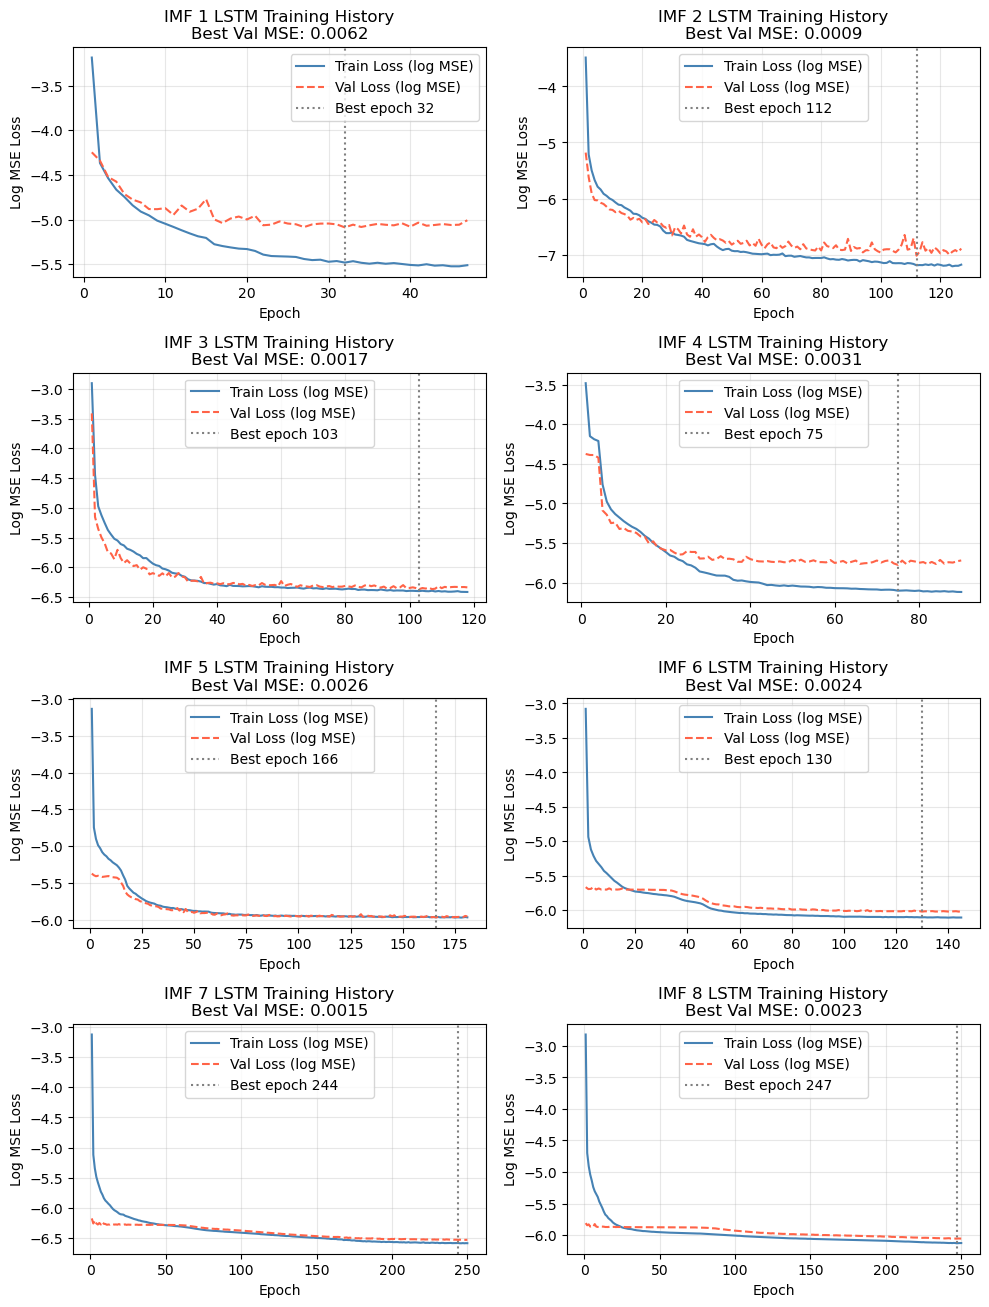

In [34]:
device = next(models[0].parameters()).device

# Collect scaled predictions — shape (N, horizon) per IMF
imf_test_preds_scaled = []
for k in range(best_K + 1):
    models[k].eval()
    preds_k = []
    with torch.no_grad():
        for batch_x, _ in imf_test_loaders[k]:
            batch_x = batch_x.to(device)
            batch_pred = models[k](batch_x).cpu().numpy()   # (batch, horizon) — no squeeze
            preds_k.append(batch_pred)
    imf_test_preds_scaled.append(np.concatenate(preds_k, axis=0))  # (N, horizon)

# Denorm each IMF per horizon column, then stack back to (N, horizon)
def denorm_per_horizon(arr_2d, scaler):
    return np.stack([
        scaler.inverse_transform(arr_2d[:, h].reshape(-1, 1)).flatten()
        for h in range(horizon)
    ], axis=1)  # (N, horizon)

imf_test_preds_raw   = [denorm_per_horizon(imf_test_preds_scaled[k],          imf_scalers[k]) for k in range(best_K + 1)]
imf_test_actuals_raw = [denorm_per_horizon(imf_y_test_list[k],                 imf_scalers[k]) for k in range(best_K + 1)]

# Sum across IMFs — still (N, horizon)
total_power_pred_raw    = np.sum(imf_test_preds_raw,    axis=0)  # (N, horizon)
total_power_actuals_raw = np.sum(imf_test_actuals_raw,  axis=0)  # (N, horizon)

assert total_power_pred_raw.shape == total_power_actuals_raw.shape

# Per-step + aggregate metrics
print("\n" + "="*60)
print("VMD-LSTM ENSEMBLE")
print("="*60)
print(f"{'Horizon':<10} {'RMSE':<12} {'MAE':<12} {'R²':<10}")
print("-" * 44)
VMD_r2_list=[]
for h in range(horizon):
    p, a = total_power_pred_raw[:, h], total_power_actuals_raw[:, h]
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    r2   = r2_score(a, p)
    VMD_r2_list.append(r2)
    print(f"t+{h+1:<8} {rmse:<12.1f} {mae:<12.1f} {r2:<10.4f}")
    
print("-" * 44)
p_flat = total_power_pred_raw.flatten()
a_flat = total_power_actuals_raw.flatten()
print(f"{'Overall':<10} {np.sqrt(mean_squared_error(a_flat, p_flat)):<12.1f} "
      f"{mean_absolute_error(a_flat, p_flat):<12.1f} {r2_score(a_flat, p_flat):<10.4f}")
print("="*60)

print("\nIMF Individual Performance")
print("=" * 50)

imf_individual_mse = []
imf_individual_r2 = []

for k in range(best_K + 1):
    # Predict IMF k
    models[k].eval()
    preds_k_scaled = []
    with torch.no_grad():
        for batch_x, batch_y in imf_test_loaders[k]:
            batch_x = batch_x.to(device)
            pred_k = models[k](batch_x).cpu().numpy()
            preds_k_scaled.append(pred_k)
    
    preds_k_raw = denorm_per_horizon(np.concatenate(preds_k_scaled), imf_scalers[k])
    actuals_k_raw = denorm_per_horizon(imf_y_test_list[k], imf_scalers[k])
    
    # Aggregate MSE across all horizons for this IMF
    mse_k = mean_squared_error(actuals_k_raw.flatten(), preds_k_raw.flatten())
    r2_k = r2_score(actuals_k_raw.flatten(), preds_k_raw.flatten())
    
    imf_individual_mse.append(mse_k)
    imf_individual_r2.append(r2_k)
    
    print(f"IMF {k+1:2d}: MSE={mse_k:8.6f}, R²={r2_k:6.4f}")

# 1. Individual IMF Training Curves (separate subplot for each) - LOG MSE SCALE
fig, axes = plt.subplots(max(2, best_K+1)//2 + 1, 2, figsize=(10, (best_K+1)*2))
axes = axes.flatten() if best_K > 0 else [axes]

for k in range(best_K+1):
    ax = axes[k]
    history_k = histories[k]
    
    epochs_k = range(1, len(history_k['train_loss']) + 1)
    best_epoch_k = history_k['val_loss'].index(min(history_k['val_loss'])) + 1
    
    # Convert losses to log scale for better visualization of convergence
    log_train_loss = np.log(history_k['train_loss'])
    log_val_loss   = np.log(history_k['val_loss'])
    
    ax.plot(epochs_k, log_train_loss, label='Train Loss (log MSE)', color='steelblue')
    ax.plot(epochs_k, log_val_loss,   label='Val Loss (log MSE)',   color='tomato', linestyle='--')
    ax.axvline(x=best_epoch_k, color='grey', linestyle=':', 
               label=f'Best epoch {best_epoch_k}')
    
    ax.set_title(f'IMF {k+1} LSTM Training History\nBest Val MSE: {min(history_k["val_loss"]):.4f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Log MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(best_K+1, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('vmd_lstm_imf_training_histories_log.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparison of $R^2$ Between Models
This plot compares the Standard vs VMD-LSTM Ensemble $R^2$ metrics as a function of horizon timestep.

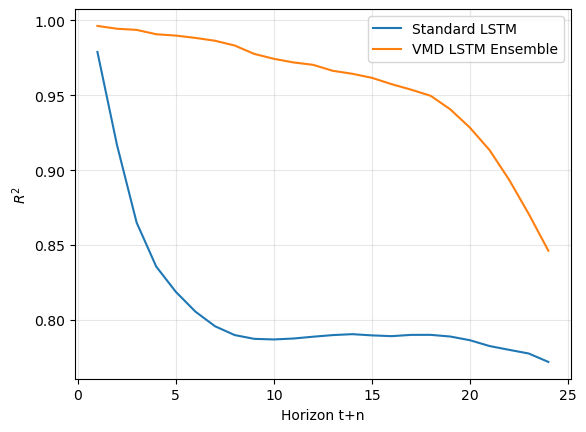

In [35]:
times = [t+1 for t in range(len(VMD_r2_list))]
plt.plot(times, standard_r2_list, label = "Standard LSTM")
plt.plot(times, VMD_r2_list, label = "VMD LSTM Ensemble")
plt.xlabel("Horizon t+n")
plt.ylabel("$R^2$")
plt.legend()
plt.grid(True, alpha=0.3)

## Investigating Lookback-Horizon length effects
This subsection investigates how lookback affects various horizons. The relevant code pipeline, from sequencing onwards, was given to Claude Sonnet 4.6 Thinking with the prompt: *"Using the provided code, create a cell that runs a hyperparameter sweep and stores results for various (lookback, horizon) pairings."*

For the visualisations of results, the prompt was: *"Visualize the hyperparameter sweep results. For each pairing in results: evaluate Standard LSTM and VMD-LSTM ensemble on test set, plot 3×2 figure with R²/RMSE curves per step (separate left/right panels), sequence availability scatter vs total window length, and mean R² vs h/lb ratio showing VMD gains with vertical lines."*

In [36]:
# ─────────────────────────────────────────────────────────────
#  Hyperparameter sweep over (lookback_steps, horizon) pairings
# ─────────────────────────────────────────────────────────────
PAIRINGS   = [ #(lookback, horizon), hours
    (12, 1),
    (24, 1),
    (48, 1),
    (24, 6),
    (48, 6),
    (48, 12),
    (72, 12),
    (48, 24),
    (72, 24),
    (168, 24),
    (96, 48)
]
BATCH_SIZE = 64

# ── helper: build a DataLoader from numpy arrays ──────────────
def make_loader(X, y, shuffle: bool) -> DataLoader:
    ds = torch.utils.data.TensorDataset(
        torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

# ── results dict: keyed by (lookback, horizon) ────────────────
results = {}

for lookback_steps, horizon in PAIRINGS:
    tag = f"lb{lookback_steps}_h{horizon}"
    min_data_needed = lookback_steps + horizon
    print(f"\n{'='*62}")
    print(f"  PAIRING  lookback={lookback_steps}h  |  horizon={horizon}h  ({tag})")
    print(f"{'='*62}")

    # ── 1. Sequences ──────────────────────────────────────────
    print("▸ Creating sequences...")
    std_X_tr, std_y_tr = create_sequences(
        train_weather_scaled, train_power_scaled, train.index.to_numpy(), lookback_steps, horizon)
    std_X_va, std_y_va = create_sequences(
        val_weather_scaled,   val_power_scaled,   val.index.to_numpy(),   lookback_steps, horizon)
    std_X_te, std_y_te = create_sequences(
        test_weather_scaled,  test_power_scaled,  test.index.to_numpy(),  lookback_steps, horizon)
    print(f"  Standard  →  train {std_X_tr.shape} / {std_y_tr.shape}")

    # ── Sequence counts ───────────────────────────────────────
    seq_counts = {
        "train" : len(std_X_tr),
        "val"   : len(std_X_va),
        "test"  : len(std_X_te),
    }
    print(f"  Sequences → train: {seq_counts['train']:,}  |  val: {seq_counts['val']:,}  |  test: {seq_counts['test']:,}")
    
    imf_X_tr, imf_y_tr = [], []
    imf_X_va, imf_y_va = [], []
    imf_X_te, imf_y_te = [], []
    for k in range(best_K + 1):
        Xtr, ytr = create_sequences(train_weather_scaled, train_imf_scaled[k], train.index.to_numpy(), lookback_steps, horizon)
        Xva, yva = create_sequences(val_weather_scaled,   val_imf_scaled[k],   val.index.to_numpy(),   lookback_steps, horizon)
        Xte, yte = create_sequences(test_weather_scaled,  test_imf_scaled[k],  test.index.to_numpy(),  lookback_steps, horizon)
        imf_X_tr.append(Xtr); imf_y_tr.append(ytr)
        imf_X_va.append(Xva); imf_y_va.append(yva)
        imf_X_te.append(Xte); imf_y_te.append(yte)

    # ── 2. DataLoaders ────────────────────────────────────────
    std_train_loader = make_loader(std_X_tr, std_y_tr, shuffle=True)
    std_val_loader   = make_loader(std_X_va, std_y_va, shuffle=False)
    std_test_loader  = make_loader(std_X_te, std_y_te, shuffle=False)

    imf_train_loaders = [make_loader(imf_X_tr[k], imf_y_tr[k], shuffle=True)  for k in range(best_K + 1)]
    imf_val_loaders   = [make_loader(imf_X_va[k], imf_y_va[k], shuffle=False) for k in range(best_K + 1)]
    imf_test_loaders  = [make_loader(imf_X_te[k], imf_y_te[k], shuffle=False) for k in range(best_K + 1)]

    # ── 3. Standard LSTM ──────────────────────────────────────
    print("▸ Training standard LSTM...")
    std_model = SolarLSTM(
        input_size  = std_X_tr.shape[-1],
        hidden_size = 64,
        num_layers  = 2,
        output_size = horizon,
        dropout     = 0.2,
    )
    std_trainer = LSTMTrainer(std_model, learning_rate=0.001)
    std_history = std_trainer.fit(std_train_loader, std_val_loader, epochs=200, patience=15)
    print(f"  Best val MSE: {min(std_history['val_loss']):.6f}")

    # ── 4. VMD-LSTM Ensemble ──────────────────────────────────
    print("▸ Training VMD-LSTM ensemble...")
    vmd_models, vmd_histories = [], []
    for k in range(best_K + 1):
        print(f"  IMF {k+1}/{best_K+1}  X{imf_X_tr[k].shape}  y{imf_y_tr[k].shape}")
        model_k = SolarLSTM(
            input_size  = imf_X_tr[k].shape[-1],
            hidden_size = 96 if k == 1 else (64 if k <= 3 else 24),
            num_layers  = 2 if k <= 3 else 1,
            output_size = horizon,
            dropout     = 0.2,
        )
        trainer_k = LSTMTrainer(model_k, learning_rate=0.001)
        history_k = trainer_k.fit(
            imf_train_loaders[k], imf_val_loaders[k],
            epochs  = 300 if k <= 2 else 250,
            patience= 15,
        )
        vmd_models.append(model_k)
        vmd_histories.append(history_k)
        print(f"    → best val MSE: {min(history_k['val_loss']):.6f}")
    print(f"  🎉 Ensemble complete for {tag}!")

    # ── 5. Store results ──────────────────────────────────────
    results[(lookback_steps, horizon)] = {
        # test arrays (needed for evaluation / plotting)
        "seq_counts"        : seq_counts,        
        "min_window_h"      : min_data_needed,
        "std_X_test"        : std_X_te,
        "std_y_test"        : std_y_te,
        "imf_X_test_list"   : imf_X_te,
        "imf_y_test_list"   : imf_y_te,
        # loaders
        "std_test_loader"   : std_test_loader,
        "imf_test_loaders"  : imf_test_loaders,
        # models
        "std_model"         : std_model,
        "vmd_models"        : vmd_models,
        # training curves
        "std_history"       : std_history,
        "vmd_histories"     : vmd_histories,
    }

    # ── 6. Checkpoint ─────────────────────────────────────────
    torch.save({
        "lookback"          : lookback_steps,
        "horizon"           : horizon,
        "std_state_dict"    : std_model.state_dict(),
        "vmd_state_dicts"   : [m.state_dict() for m in vmd_models],
        "imf_scalers"       : imf_scalers,
        "std_history"       : std_history,
        "vmd_histories"     : vmd_histories,
    }, f"vmd_lstm_{tag}.pth")
    print(f"  ✓ Checkpoint saved → vmd_lstm_{tag}.pth")

print("\n✅ All pairings complete!")
print(f"   Stored keys: {list(results.keys())}")



  PAIRING  lookback=12h  |  horizon=1h  (lb12_h1)
▸ Creating sequences...
  Standard  →  train (16322, 12, 8) / (16322, 1)
  Sequences → train: 16,322  |  val: 3,484  |  test: 3,485
▸ Training standard LSTM...
CUDA available: True
Device selected: cuda
Model device after .to(): cuda:0
Starting training...
Device: cuda
Model parameters: 56,449
Training samples: 16322
Validation samples: 3484
------------------------------------------------------------
Epoch 1, Train: 0.011399, Val: 0.004306
Epoch 2, Train: 0.004003, Val: 0.003276
Epoch 3, Train: 0.002627, Val: 0.000978
Epoch 4, Train: 0.002111, Val: 0.001429
Epoch 5, Train: 0.002097, Val: 0.001400
Epoch 6, Train: 0.001779, Val: 0.002377
LR reduced: 1.000000e-03 -> 5.000000e-04
Epoch 7, Train: 0.001721, Val: 0.001151
Epoch 8, Train: 0.001530, Val: 0.001161
Epoch 9, Train: 0.001546, Val: 0.001702
Epoch 10, Train: 0.001526, Val: 0.000837
Epoch 11, Train: 0.001544, Val: 0.000909
Epoch 12, Train: 0.001417, Val: 0.001318
Epoch 13, Train: 0.0

Evaluating lb= 12, h= 1h ...  Std R²=0.9939  VMD R²=0.9990
Evaluating lb= 24, h= 1h ...  Std R²=0.9903  VMD R²=0.9991
Evaluating lb= 48, h= 1h ...  Std R²=0.9935  VMD R²=0.9987
Evaluating lb= 24, h= 6h ...  Std R²=0.8789  VMD R²=0.9952
Evaluating lb= 48, h= 6h ...  Std R²=0.8780  VMD R²=0.9954
Evaluating lb= 48, h=12h ...  Std R²=0.8320  VMD R²=0.9865
Evaluating lb= 72, h=12h ...  Std R²=0.8231  VMD R²=0.9874
Evaluating lb= 48, h=24h ...  Std R²=0.7931  VMD R²=0.9568
Evaluating lb= 72, h=24h ...  Std R²=0.7911  VMD R²=0.9577
Evaluating lb=168, h=24h ...  Std R²=0.7740  VMD R²=0.9482
Evaluating lb= 96, h=48h ...  Std R²=0.7553  VMD R²=0.8180


C:\Users\Rapha\AppData\Local\Temp\ipykernel_12336\991694275.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab20", n)
C:\Users\Rapha\AppData\Local\Temp\ipykernel_12336\991694275.py:171: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hrz_palette     = plt.cm.get_cmap("tab10", len(unique_horizons))


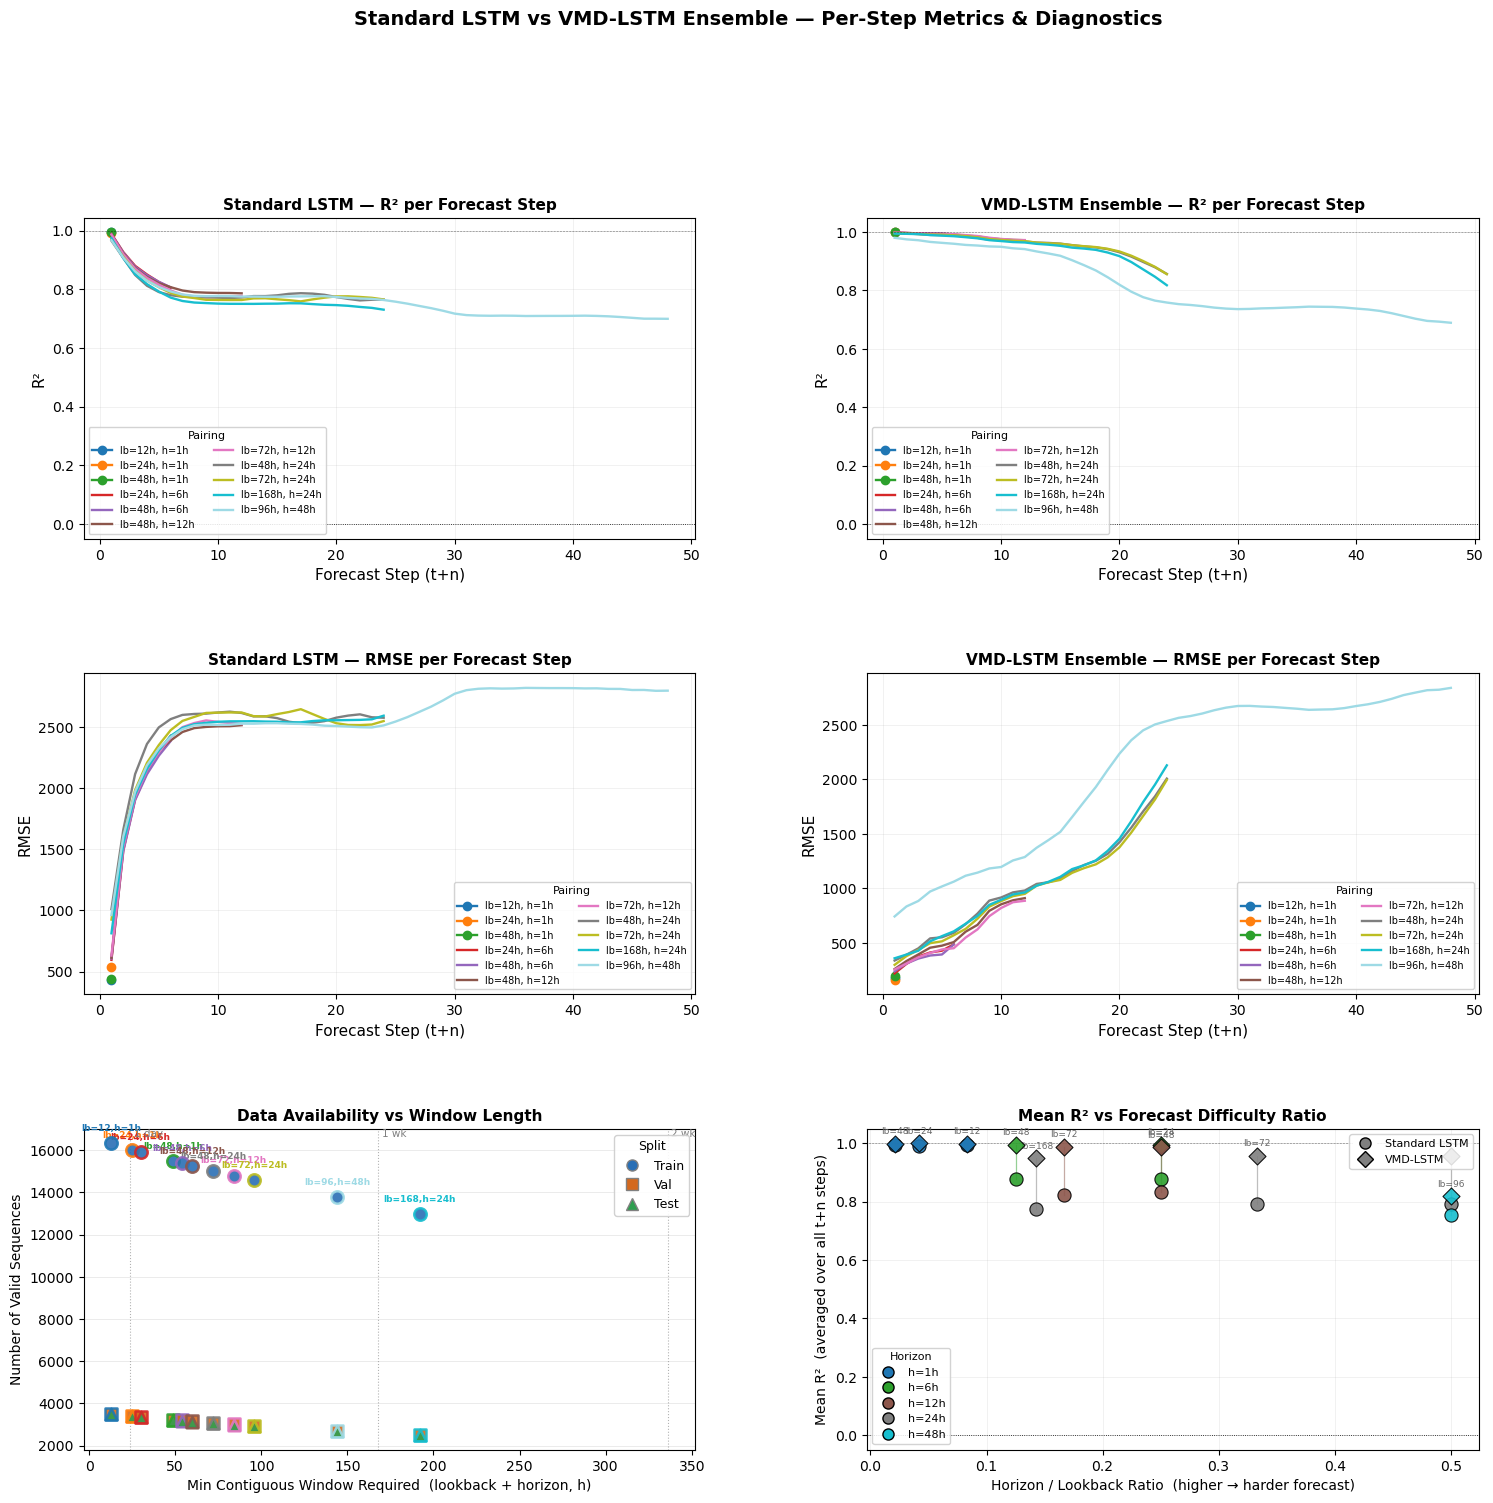

✓ Saved → pairing_metrics_3x2.png


In [37]:
# ─────────────────────────────────────────────────────────────
#  CELL: Evaluate all pairings → per-step R² and RMSE plots
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
from sklearn.metrics import mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── helpers ───────────────────────────────────────────────────
def _denorm(arr_2d, scaler, horizon):
    """Inverse-transform each horizon column independently."""
    return np.stack([
        scaler.inverse_transform(arr_2d[:, h].reshape(-1, 1)).flatten()
        for h in range(horizon)
    ], axis=1)

def eval_standard(model, test_loader, scaler, horizon):
    model.eval()
    preds, acts = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            preds.append(model(bx.to(device)).cpu().numpy())
            acts.append(by.numpy())
    preds_d = _denorm(np.concatenate(preds), scaler, horizon)
    acts_d  = _denorm(np.concatenate(acts),  scaler, horizon)
    r2   = [r2_score(acts_d[:, h],                   preds_d[:, h])                   for h in range(horizon)]
    rmse = [np.sqrt(mean_squared_error(acts_d[:, h],  preds_d[:, h]))  for h in range(horizon)]
    return r2, rmse

def eval_vmd(vmd_models, imf_test_loaders, imf_scalers, best_K, horizon):
    # collect scaled preds and actuals from loaders
    imf_preds, imf_acts = [], []
    for k in range(best_K + 1):
        vmd_models[k].eval()
        pk, ak = [], []
        with torch.no_grad():
            for bx, by in imf_test_loaders[k]:
                pk.append(vmd_models[k](bx.to(device)).cpu().numpy())
                ak.append(by.numpy())
        imf_preds.append(_denorm(np.concatenate(pk), imf_scalers[k], horizon))
        imf_acts.append( _denorm(np.concatenate(ak), imf_scalers[k], horizon))

    total_pred = np.sum(imf_preds, axis=0)   # (N, horizon)
    total_acts = np.sum(imf_acts,  axis=0)

    r2   = [r2_score(total_acts[:, h],                   total_pred[:, h])                   for h in range(horizon)]
    rmse = [np.sqrt(mean_squared_error(total_acts[:, h],  total_pred[:, h]))  for h in range(horizon)]
    return r2, rmse

# ── run all evaluations ───────────────────────────────────────
eval_results = {}
for (lb, h), r in results.items():
    print(f"Evaluating lb={lb:3d}, h={h:2d}h ...", end="  ")
    std_r2, std_rmse = eval_standard(
        r["std_model"], r["std_test_loader"], power_scaler, h)
    vmd_r2, vmd_rmse = eval_vmd(
        r["vmd_models"], r["imf_test_loaders"], imf_scalers, best_K, h)
    eval_results[(lb, h)] = {
        "std_r2": std_r2, "std_rmse": std_rmse,
        "vmd_r2": vmd_r2, "vmd_rmse": vmd_rmse,
    }
    print(f"Std R²={np.mean(std_r2):.4f}  VMD R²={np.mean(vmd_r2):.4f}")

# ── colour palette: one colour per pairing ────────────────────
n = len(eval_results)
palette = cm.get_cmap("tab20", n)
colors  = {key: palette(i) for i, key in enumerate(eval_results)}

# ─────────────────────────────────────────────────────────────
#  3×2 plot: Standard LSTM (left) vs VMD-LSTM (right)
#            R² (top) | RMSE (mid) | diagnostics (bottom)
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.28)

ax_std_r2    = fig.add_subplot(gs[0, 0])
ax_vmd_r2    = fig.add_subplot(gs[0, 1])
ax_std_rmse  = fig.add_subplot(gs[1, 0])
ax_vmd_rmse  = fig.add_subplot(gs[1, 1])
ax_seq       = fig.add_subplot(gs[2, 0])
ax_ratio     = fig.add_subplot(gs[2, 1])

fig.suptitle("Standard LSTM vs VMD-LSTM Ensemble — Per-Step Metrics & Diagnostics",
             fontsize=14, fontweight="bold", y=1.01)

# ── rows 1 & 2: metric line plots ────────────────────────────
PLOT_CFG = [
    (ax_std_r2,   "std_r2",   "R²",   "Standard LSTM — R² per Forecast Step"),
    (ax_vmd_r2,   "vmd_r2",   "R²",   "VMD-LSTM Ensemble — R² per Forecast Step"),
    (ax_std_rmse, "std_rmse", "RMSE", "Standard LSTM — RMSE per Forecast Step"),
    (ax_vmd_rmse, "vmd_rmse", "RMSE", "VMD-LSTM Ensemble — RMSE per Forecast Step"),
]

for ax, metric_key, ylabel, title in PLOT_CFG:
    for (lb, h), er in eval_results.items():
        x     = np.arange(1, h + 1)
        c     = colors[(lb, h)]
        label = f"lb={lb}h, h={h}h"
        mkr   = "o" if h == 1 else None

        ax.plot(x, er[metric_key], color=c, lw=1.7,
                marker=mkr, markersize=6, label=label)

    ax.set_xlabel("Forecast Step (t+n)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="semibold")

    if ylabel == "R²":
        ax.axhline(0,   color="black", lw=0.6, ls=":")
        ax.axhline(1.0, color="black", lw=0.4, ls=":")
        #ax.set_ylim(-0.15, 1.05)
    ax.legend(fontsize=7, ncol=2, title="Pairing", title_fontsize=8,
              loc="lower left" if ylabel == "R²" else "lower right",
              framealpha=0.85)
    ax.grid(True, alpha=0.25, lw=0.5)

# ── row 3 left: sequence counts vs min_window_h ──────────────
split_colors = {"train": "#2a6fb5", "val": "#d4691e", "test": "#2e9e4f"}
split_markers = {"train": "o", "val": "s", "test": "^"}
split_sizes   = {"train": 80,  "val": 70,  "test": 70}

for (lb, h), r in results.items():
    win = r["min_window_h"]
    sc  = r["seq_counts"]
    c   = colors[(lb, h)]

    for split in ("train", "val", "test"):
        ax_seq.scatter(win, sc[split],
                       color=split_colors[split],
                       edgecolors=c, linewidths=1.8,
                       marker=split_markers[split],
                       s=split_sizes[split],
                       alpha=0.9, zorder=4)

    ax_seq.annotate(
        f"lb={lb},h={h}h",
        xy=(win, sc["train"]),
        xytext=(0, 9), textcoords="offset points",
        fontsize=6.5, ha="center", color=c, fontweight="bold",
    )

# reference verticals
for ref_h, lbl in [(24, "1 day"), (168, "1 wk"), (336, "2 wk")]:
    ax_seq.axvline(ref_h, color="grey", lw=0.8, ls=":", alpha=0.6)
    ax_seq.text(ref_h + 2, ax_seq.get_ylim()[1] if ax_seq.get_ylim()[1] > 0 else 1000,
                lbl, fontsize=7.5, color="grey", va="top")

seq_handles = [
    mlines.Line2D([], [], marker=split_markers[s], color="w",
                  markerfacecolor=split_colors[s], markeredgecolor="grey",
                  markersize=8, label=s.capitalize())
    for s in ("train", "val", "test")
]
ax_seq.legend(handles=seq_handles, fontsize=9, title="Split",
              title_fontsize=9, loc="upper right", framealpha=0.9)
ax_seq.set_xlabel("Min Contiguous Window Required  (lookback + horizon, h)", fontsize=10)
ax_seq.set_ylabel("Number of Valid Sequences", fontsize=10)
ax_seq.set_title("Data Availability vs Window Length", fontsize=11, fontweight="semibold")
ax_seq.grid(axis="y", lw=0.5, alpha=0.35)

# ── row 3 right: mean R² vs horizon/lookback ratio ───────────
# one colour per unique horizon value
unique_horizons = sorted(set(h for (_, h) in eval_results))
hrz_palette     = plt.cm.get_cmap("tab10", len(unique_horizons))
hrz_color       = {h: hrz_palette(i) for i, h in enumerate(unique_horizons)}

for (lb, h), er in eval_results.items():
    ratio    = h / lb
    std_mean = float(np.mean(er["std_r2"]))
    vmd_mean = float(np.mean(er["vmd_r2"]))
    c        = hrz_color[h]
    label    = f"h={h}h"

    ax_ratio.scatter(ratio, std_mean,
                     color=c, marker="o", s=90,
                     edgecolors="black", linewidths=0.8,
                     alpha=0.9, zorder=4,
                     label=f"h={h}h (STD)" if lb == min(k[0] for k in eval_results if k[1]==h) else "")
    ax_ratio.scatter(ratio, vmd_mean,
                     color=c, marker="D", s=75,
                     edgecolors="black", linewidths=0.8,
                     alpha=0.9, zorder=4,
                     label=f"h={h}h (VMD)" if lb == min(k[0] for k in eval_results if k[1]==h) else "")

    # connect std and vmd for the same pairing with a thin vertical line
    ax_ratio.plot([ratio, ratio], [std_mean, vmd_mean],
                  color=c, lw=0.9, alpha=0.5, zorder=3)

    # annotate with lb value
    ax_ratio.annotate(
        f"lb={lb}",
        xy=(ratio, max(std_mean, vmd_mean)),
        xytext=(0, 7), textcoords="offset points",
        fontsize=6.5, ha="center", color="dimgrey",
    )

ax_ratio.axhline(0,   color="black", lw=0.6, ls=":")
ax_ratio.axhline(1.0, color="black", lw=0.4, ls=":")
ax_ratio.set_xlabel("Horizon / Lookback Ratio  (higher → harder forecast)", fontsize=10)
ax_ratio.set_ylabel("Mean R²  (averaged over all t+n steps)", fontsize=10)
ax_ratio.set_title("Mean R² vs Forecast Difficulty Ratio", fontsize=11, fontweight="semibold")
ax_ratio.grid(True, alpha=0.25, lw=0.5)

# legend: horizon colours + model shape
hrz_handles = [
    mlines.Line2D([], [], marker="o", color="w",
                  markerfacecolor=hrz_color[h], markeredgecolor="black",
                  markersize=8, label=f"h={h}h")
    for h in unique_horizons
]
shape_handles = [
    mlines.Line2D([], [], marker="o", color="w", markerfacecolor="grey",
                  markeredgecolor="black", markersize=8, label="Standard LSTM"),
    mlines.Line2D([], [], marker="D", color="w", markerfacecolor="grey",
                  markeredgecolor="black", markersize=8, label="VMD-LSTM"),
]
leg1 = ax_ratio.legend(handles=hrz_handles,  loc="lower left",  fontsize=8,
                        title="Horizon", title_fontsize=8, framealpha=0.85)
ax_ratio.add_artist(leg1)
ax_ratio.legend(handles=shape_handles, loc="upper right", fontsize=8, framealpha=0.85)

plt.savefig("pairing_metrics_3x2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → pairing_metrics_3x2.png")

# Stage 2: Generalised LSTM using Weather, Power, and Static Data.

## Loading Metadata

#### Reading metadata file
We load the weather files using `load_metadata(filename)`, as defined in the preamble. This cell returns a pandas dataframe `df_metadata`.

In [38]:
df_metadata = load_metadata('PV_generation_system_metadata.ttl') #filename

✓ Extracted metadata for 60 stations

Columns: ['station_id', 'latitude', 'longitude', 'location', 'altitude_m', 'capacity_kw', 'azimuth', 'tilt_angle', 'connection_date', 'contractor']

Capacity range: 3.7 - 249.5 kW
Total capacity: 2230.81 kW

Missing values:
station_id         0
latitude           0
longitude          0
location           6
altitude_m         0
capacity_kw        0
azimuth            0
tilt_angle         0
connection_date    0
contractor         0
dtype: int64


#### Parsing azimuth column
Panel azimuth is encoded as $\sin(\phi), \cos(\phi)$ to preserve its circular geometry. Without this, a model would incorrectly treat 359° and 1° as maximally distant. For stations with split panel orientations (e.g. "90/270"), the components are averaged in sin/cos space rather than in degree space, avoiding the circular mean problem.

Tilt is a linear quantity and is parsed directly as a scalar, with range values (e.g. "10/20") averaged numerically. 

Stations marked "Mixed" for either field are assigned a binary flag (`is_mixed_azimuth, is_mixed_tilt`) and their numeric values filled with 0.0 — a neutral value — rather than the median, to avoid implying a spurious orientation for geometrically undefined stations.

In [39]:
def parse_azimuth_to_sincos(angle_str):
    """Encode azimuth in circular sin/cos space. Ranges averaged in sin/cos space."""
    if pd.isna(angle_str) or str(angle_str).strip() == 'Mixed':
        return np.nan, np.nan
    s = str(angle_str).strip().replace('deg', '')
    if '/' in s:
        vals = [float(x.strip()) for x in s.split('/')]
        sins = np.mean([np.sin(2 * np.pi * v / 360) for v in vals])
        coss = np.mean([np.cos(2 * np.pi * v / 360) for v in vals])
        return sins, coss
    v = float(s)
    return np.sin(2 * np.pi * v / 360), np.cos(2 * np.pi * v / 360)

def parse_tilt(angle_str):
    """Parse tilt: ranges → mean, Mixed → NaN."""
    if pd.isna(angle_str) or str(angle_str).strip() == 'Mixed':
        return np.nan
    s = str(angle_str).strip().replace('deg', '')
    if '/' in s:
        vals = [float(x.strip()) for x in s.split('/')]
        return np.mean(vals)
    return float(s)

# Parse azimuth into sin/cos directly
df_metadata[['azimuth_sin', 'azimuth_cos']] = df_metadata['azimuth'].apply(
    lambda x: pd.Series(parse_azimuth_to_sincos(x))
)

# Parse tilt
df_metadata['tilt_num'] = df_metadata['tilt_angle'].apply(parse_tilt)

# Binary Mixed flags — before fillna so NaN still means Mixed
df_metadata['is_mixed_azimuth'] = (df_metadata['azimuth'] == 'Mixed').astype(float)
df_metadata['is_mixed_tilt']    = (df_metadata['tilt_angle'] == 'Mixed').astype(float)

# Fill NaN with 0 (neutral) — not median
df_metadata['azimuth_sin'] = df_metadata['azimuth_sin'].fillna(0.0)
df_metadata['azimuth_cos'] = df_metadata['azimuth_cos'].fillna(0.0)
df_metadata['tilt_num']    = df_metadata['tilt_num'].fillna(0.0)

print(df_metadata[['station_id', 'azimuth', 'azimuth_sin', 'azimuth_cos',
                    'tilt_angle', 'tilt_num', 'is_mixed_azimuth', 'is_mixed_tilt']].to_string())

                        station_id     azimuth   azimuth_sin   azimuth_cos tilt_angle  tilt_num  is_mixed_azimuth  is_mixed_tilt
0                  CYT__Station_1_   90/-90deg  0.000000e+00  6.123234e-17      10deg      10.0               0.0            0.0
1                  CYT__Station_2_   90/-90deg  0.000000e+00  6.123234e-17      10deg      10.0               0.0            0.0
2              Indoor_Sport_Center    0/180deg  6.123234e-17  0.000000e+00      10deg      10.0               0.0            0.0
3                        LSK_North  10/-153deg -1.401712e-01  4.690061e-02      10deg      10.0               0.0            0.0
4                        LSK_South        0deg  0.000000e+00  1.000000e+00       0deg       0.0               0.0            0.0
5                          Library       Mixed  0.000000e+00  0.000000e+00      10deg      10.0               1.0            0.0
6                              SQ1        0deg  0.000000e+00  1.000000e+00       0deg       0.0  

#### Mapping Power stations between dataframes
This cell renames the weather+power `df`'s stations columns to match with those in the metadata. This is stored as `df_renamed`, so as to preserve `df` for previous code to be re-run.

In [40]:
# Exact mapping based on your power_features vs metadata station_id
station_mapping = {
    'CYT (Station 1)': 'CYT__Station_1_',
    'CYT (Station 2)': 'CYT__Station_2_',
    'Indoor Sports Centre': 'Indoor_Sport_Center',
    'LSK North': 'LSK_North',
    'LSK South': 'LSK_South',
    'S H Ho Sports Hall': 'S_H_Ho_Sports_Hall',
    'Shaw Auditorium': 'Shaw_Auditorium',
    'Tower A': 'Tower_A',
    'Wong Check She Research Centre': 'Wong_Check_She_Research_Centre',
    'Zone A1': 'Zone_A1',
    'Zone A2': 'Zone_A2',
    'Zone A4': 'Zone_A4',
    'Zone A5': 'Zone_A5',
    'Zone A6': 'Zone_A6',
    'Zone A7': 'Zone_A7',
    'Zone D': 'Zone_D',
    'Zone J1': 'Zone_J1',
    'Zone J2': 'Zone_J2',
    'Zone L1 (Station 1)': 'Zone_L1__Station_1_',
    'Zone L1(Station 2)': 'Zone_L1__Station_2_',
    'Zone L2': 'Zone_L2',
    'SQ Block P': 'SQ_Block_P',
    'SQ Block Q': 'SQ_Block_Q',
    'SQ Block Q (Phrase 2)': 'SQ_Block_Q__Phrase_2_',
    'SQ Block R': 'SQ_Block_R',
    'SQ Block S': 'SQ_Block_S',
    'SQ Apartment1-12': 'SQ_Apartment1_12',
    'SQ Apartment13-24': 'SQ_Apartment13_24',
    'SQ Apartment25-36': 'SQ_Apartment25_36',
    'SQ Apartment37-48': 'SQ_Apartment37_48',
    'SQ567 Flexible PV': 'SQ567_Flexible_PV',
    'SQ Apartment37-48 Flexible PV': 'SQ_Apartment37_48_Flexible_PV',
    'UG Hall2 2F': 'UG_Hall2_2F',
    'UG Hall2 RF': 'UG_Hall2_RF',
    'UG Hall3': 'UG_Hall3',
    'UG Hall4': 'UG_Hall4',
    'UG Hall4 Flexible PV': 'UG_Hall4_Flexible_PV',
    'UG Hall6': 'UG_Hall6',
    'UG Hall7': 'UG_Hall7',
    'UG Hall7 Flexible PV': 'UG_Hall7_Flexible_PV',
    'UG Hall8': 'UG_Hall8',
    'UG Hall9': 'UG_Hall9',
    "Library" : "Library",
    "SQ1" : "SQ1",
    "SQ10" : "SQ10",
    "SQ11" : "SQ11",
    "SQ12" : "SQ12",
    "SQ13" : "SQ13",
    "SQ14" : "SQ14",
    "SQ15" : "SQ15",
    "SQ16" : "SQ16",
    "SQ17" : "SQ17",
    "SQ18" : "SQ18",
    "SQ19" : "SQ19",
    "SQ2" : "SQ2",
    "SQ3" : "SQ3",
    "SQ4" : "SQ4",
    "SQ567" : "SQ567",
    "SQ8" : "SQ8",
    "SQ9" : "SQ9"
}

In [41]:
# Rename df columns to match metadata
df_renamed = df.rename(columns=station_mapping)

#### Forming Long Dataframe
The wide dataframe, `df_renamed` with one column per station PV, is melted into a long format with a row per (timestep, station) observation. 

Static metadata — capacity, altitude, azimuth, tilt, and mixed-orientation flags — are joined per station.

Generated by Claude Sonnet 4.6 Thinking. Prompt: *"I have a wide DataFrame df_renamed where each column is a station's power output, alongside shared weather features. Melt it into long format with one row per (timestamp, station) pair, merge in station metadata (columns stored in statics), sort by station then time, and verify SQ19's non-null power date range. Call the result df_p2LSTM."*

In [42]:
# Melt with Time as id_var (already a column after reset_index)
df_reset = df_renamed.reset_index()
df_p2LSTM = df_reset.melt(
    id_vars=weather_features + ['Time'],
    value_vars=list(station_mapping.values()),
    var_name='station_id',
    value_name='power'
).copy()

df_p2LSTM['Time'] = pd.to_datetime(df_p2LSTM['Time'])
df_p2LSTM = df_p2LSTM.reset_index(drop=True)

statics = [#'latitude', 'longitude', 
    'altitude_m', 'capacity_kw', 'azimuth_sin', 'azimuth_cos', 'tilt_num',
    'is_mixed_azimuth', 'is_mixed_tilt'
]
# Merge metadata
df_p2LSTM = df_p2LSTM.merge(
    df_metadata[statics+['station_id']],
    on='station_id',
    how='left'
)

df_p2LSTM = df_p2LSTM.sort_values(['station_id', 'Time'])

print('df_p2LSTM ready:', df_p2LSTM.shape)

# Verify SQ19
sq19 = df_p2LSTM[df_p2LSTM['station_id'] == 'SQ19'].dropna(subset=['power'])
print(f'SQ19 first non-null power: {sq19["Time"].min()}')
print(f'SQ19 last non-null power:  {sq19["Time"].max()}')

df_p2LSTM ready: (1470060, 14)
SQ19 first non-null power: 2021-03-10 00:00:00
SQ19 last non-null power:  2023-12-31 10:00:00


#### Cleaning: NaN Removal, Clipping, and Anomaly Handling
Rows with any NaN are dropped, and power values are clipped to zero to remove physically impossible negative readings. Power is then normalised by rated capacity per station to give `powerscaled`. This allows for fair comparison and joint training across stations of different sizes.

Three stations (`Tower_A, SQ9, UG_Hall4_Flexible_PV`) exhibit transient spikes with `powerscaled > 1.0`, likely due to inaccurate capacity metadata or inverter clipping artefacts. Spike rows are dropped rather than clipped to avoid training the model on unrepresentative peak behaviour. Remaining values are clipped to `powerscaled = 1.0`.

SQ567_Flexible_PV is removed entirely due to a sudden drop in capacity during its lifetime, seen in the plot below.

In [43]:
df_p2LSTM = df_p2LSTM.dropna()
df_p2LSTM["power"] = np.clip(df_p2LSTM["power"], 0, None)

In [44]:
df_p2LSTM["powerscaled"] = df_p2LSTM["power"]/(df_p2LSTM["capacity_kw"]*1000)

In [45]:
# Where are the >1 values coming from?
overflow = df_p2LSTM[df_p2LSTM["powerscaled"] > 1]

print(f"Overflow rows: {len(overflow)}")
print("\n=== Which stations? ===")
print(overflow.groupby("station_id").agg(
    count=("powerscaled", "count"),
    max_scaled=("powerscaled", "max"),
    max_power_W=("power", "max"),
    capacity_kw=("capacity_kw", "first")
).sort_values("max_scaled", ascending=False))


Overflow rows: 229

=== Which stations? ===
                               count  max_scaled   max_power_W  capacity_kw
station_id                                                                 
Tower_A                            2  788.163936  3.175512e+07        40.29
SQ9                                1   41.978741  1.293365e+06        30.81
UG_Hall4_Flexible_PV               2    8.963054  1.778270e+05        19.84
SQ_Apartment37_48_Flexible_PV     72    1.292339  4.807500e+03         3.72
Zone_D                            41    1.114021  7.644415e+04        68.62
UG_Hall2_RF                       45    1.048677  8.389417e+03         8.00
SQ_Apartment13_24                 15    1.002132  1.703625e+04        17.00
SQ_Apartment25_36                 17    1.000554  1.700942e+04        17.00
Indoor_Sport_Center               21    1.000492  3.331639e+04        33.30
SQ_Apartment1_12                  11    1.000417  1.700708e+04        17.00
SQ1                                1    1.00

In [46]:
spike_stations = ["Tower_A", "SQ9", "UG_Hall4_Flexible_PV"]
spike_mask = (df_p2LSTM["station_id"].isin(spike_stations)) & (df_p2LSTM["powerscaled"] > 1.0)
print(f"Dropping {spike_mask.sum()} spike rows")
df_p2LSTM = df_p2LSTM[~spike_mask].copy()

#Clip rest
df_p2LSTM["powerscaled"] = df_p2LSTM["powerscaled"].clip(0.0, 1.0)

Dropping 5 spike rows


count    19577.000000
mean         0.059620
std          0.116109
min          0.000000
25%          0.000000
50%          0.000000
75%          0.060394
max          0.588441
Name: powerscaled, dtype: float64

Zero readings: 59.3%
Near-zero (<0.01): 63.7%


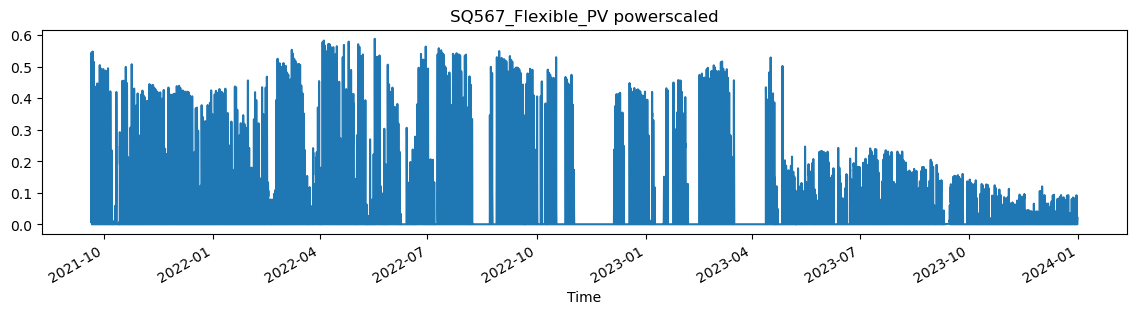

In [47]:
sq567_flex = df_p2LSTM[df_p2LSTM['station_id'] == 'SQ567_Flexible_PV']
print(sq567_flex['powerscaled'].describe())
print(f"\nZero readings: {(sq567_flex['powerscaled'] == 0).mean():.1%}")
print(f"Near-zero (<0.01): {(sq567_flex['powerscaled'] < 0.01).mean():.1%}")

# Plot the raw power series
import matplotlib.pyplot as plt
sq567_flex.set_index('Time')['powerscaled'].plot(figsize=(14,3), title='SQ567_Flexible_PV powerscaled')
plt.show()
df_p2LSTM = df_p2LSTM[~df_p2LSTM['station_id'].isin(['SQ567_Flexible_PV'])].copy()

#### Adding Optimizer info
A binary `optimizer` feature is added to indicate whether a station uses a power optimizer. This is mapped from the station metadata dictionary and encoded as `1` (uses optimizer) or `0` (does not), allowing the model to condition on this hardware difference across stations.

In [48]:
# Invert station_mapping: underscore_name → display_name
reverse_mapping = {v: k for k, v in station_mapping.items()}

# Map: station_id (underscore) → display name → optimizer bool → 0/1
df_p2LSTM["optimizer"] = (
    df_p2LSTM["station_id"]
    .map(reverse_mapping)       # underscore → display name
    .map(optimizer_info)        # display name → True/False
    .astype(int)                # True/False → 1/0
)
statics += ['optimizer']

## Feature Engineering

#### Cyclically Encoding Solar Position
Solar zenith and azimuth are computed for each timestep using pvlib and cyclically encoded. This directly informs the model of the sun's physical position, capturing seasonal and diurnal generation patterns that may not be fully recoverable from time encodings alone. Approximate coordinates for Hong Kong (`latitude=22.3, longitude=114.2, altitude=50`) are used, as precise station locations are unavailable and further precision is unnecessary.

In [49]:
# Hong Kong central coordinates (covers most panels across territory)
hk_central = pvlib.location.Location(
    latitude=22.3, 
    longitude=114.2, 
    tz='Asia/Hong_Kong',  # or 'UTC+8'
    altitude=50  # conservative avg
)
# Compute solar position on UNIQUE timestamps only
unique_times = df_p2LSTM['Time'].drop_duplicates().sort_values()

solar_position = hk_central.get_solarposition(unique_times)

# Map back to df_p2LSTM via Time column
df_p2LSTM['zenith'] = df_p2LSTM['Time'].map(solar_position['apparent_zenith'])
df_p2LSTM['azimuth'] = df_p2LSTM['Time'].map(solar_position['azimuth'])  # renamed to avoid clash with panel azimuth col

print("SZA sample:")
print(df_p2LSTM[['Time', 'zenith', 'azimuth']].head(10).round(1))
print(f"\nNight stats (zenith>95°): {len(df_p2LSTM[df_p2LSTM['zenith'] > 95]):,} / {len(df_p2LSTM):,} ({100*len(df_p2LSTM[df_p2LSTM['zenith'] > 95])/len(df_p2LSTM):.1f}%)")

SZA sample:
                    Time  zenith  azimuth
1345 2021-05-05 01:00:00    47.3     88.1
1346 2021-05-05 02:00:00    33.5     94.1
1347 2021-05-05 03:00:00    19.8    104.2
1348 2021-05-05 04:00:00     7.6    141.1
1349 2021-05-05 05:00:00    11.2    239.4
1350 2021-05-05 06:00:00    24.3    260.2
1351 2021-05-05 07:00:00    38.1    268.3
1352 2021-05-05 08:00:00    52.0    273.8
1353 2021-05-05 09:00:00    65.8    278.6
1354 2021-05-05 10:00:00    79.3    283.5

Night stats (zenith>95°): 524,488 / 1,134,170 (46.2%)


In [50]:
# Zenith (0-180° → period=360 for full circle continuity at sunrise/sunset)
df_p2LSTM['solar_zenith_sin'] = np.sin(2 * np.pi * df_p2LSTM['zenith'] / 360)
df_p2LSTM['solar_zenith_cos'] = np.cos(2 * np.pi * df_p2LSTM['zenith'] / 360)

# Azimuth (0-360° → period=360 standard)
df_p2LSTM['solar_azimuth_sin'] = np.sin(2 * np.pi * df_p2LSTM['azimuth'] / 360)
df_p2LSTM['solar_azimuth_cos'] = np.cos(2 * np.pi * df_p2LSTM['azimuth'] / 360)

# Drop raw angles (redundant)
df_p2LSTM.drop(columns=['zenith', 'azimuth'], inplace=True)

#### Train/val/test split
A temporal split of approximately 80% / 10% / 10% is applied across the global time axis, preserving chronological ordering and preventing data leakage. Cutoffs are computed from the sorted unique timestamps rather than row counts, ensuring consistency across stations with different recording densities.

Stations that begin recording after the training cutoff (SQ_Block_P, Shaw_Auditorium) are dropped prior to splitting — retaining them would mean the model has never seen their data during training, and evaluating zero-shot station generalisation is outside the scope of this study. Cutoffs are then recomputed on the 57 remaining stations.

The final split yields 75.8% train / 12.1% val / 12.2% test, with cutoffs at 2023-06-07 and 2023-09-21.

This cell was generated by Claude Sonnet 4.6 Thinking. Prompt: *"Split df_p2LSTM 80/10/10 by time, on column 'Time'. First detect any stations that start after the train cutoff — print and drop them, then recompute the cutoffs on the pruned data. Always write the result to df_p2LSTM_dropped whether or not anything was dropped, so downstream code is consistent. Print a summary of what was dropped and the final split row counts and percentages."*

In [51]:
# Step 1: Initial cut on full df_p2LSTM
all_timestamps = df_p2LSTM['Time'].sort_values().unique()
n = len(all_timestamps)
global_train_cutoff = all_timestamps[int(0.8 * n)]
global_val_cutoff = all_timestamps[int(0.9 * n)]

print(f'Initial cuts: train={global_train_cutoff}, val={global_val_cutoff}')

# Step 2: Find late stations
station_first_timestamp = df_p2LSTM.groupby('station_id')['Time'].min()
missing_from_train = [(s, ts) for s, ts in station_first_timestamp.items() 
                      if ts > global_train_cutoff]

if missing_from_train:
    stations_to_drop = [s for s, _ in missing_from_train]
    print(f'\n⚠️  Dropping {len(stations_to_drop)} late stations:')
    for station, first_ts in missing_from_train:
        print(f'   {station}: starts {first_ts}')

    # Step 3: Copy without late stations (preserves original df_p2LSTM)
    df_p2LSTM_dropped = df_p2LSTM[~df_p2LSTM['station_id'].isin(stations_to_drop)].copy()
    print(f'\nRemaining stations: {df_p2LSTM_dropped["station_id"].nunique()}')
    print(f'Kept stations: {sorted(df_p2LSTM_dropped["station_id"].unique().tolist())}')

    # Step 4: Recompute cuts on cleaned df
    all_timestamps = df_p2LSTM_dropped['Time'].sort_values().unique()
    n = len(all_timestamps)
    global_train_cutoff = all_timestamps[int(0.8 * n)]
    global_val_cutoff = all_timestamps[int(0.9 * n)]
    print(f'\nRecomputed cuts: train={global_train_cutoff}, val={global_val_cutoff}')
else:
    df_p2LSTM_dropped = df_p2LSTM.copy()
    print('✅ All stations present in train, no drops needed.')

# Step 5: Split
p2LSTM_train = df_p2LSTM_dropped[df_p2LSTM_dropped['Time'] <= global_train_cutoff].copy()
p2LSTM_val = df_p2LSTM_dropped[(df_p2LSTM_dropped['Time'] > global_train_cutoff) & 
                        (df_p2LSTM_dropped['Time'] <= global_val_cutoff)].copy()
p2LSTM_test = df_p2LSTM_dropped[df_p2LSTM_dropped['Time'] > global_val_cutoff].copy()

print(f'\nFinal split:')
print(f'Train: {len(p2LSTM_train)/len(df_p2LSTM_dropped)*100:.1f}% ({len(p2LSTM_train):,} rows)')
print(f'Val:   {len(p2LSTM_val)/len(df_p2LSTM_dropped)*100:.1f}% ({len(p2LSTM_val):,} rows)')
print(f'Test:  {len(p2LSTM_test)/len(df_p2LSTM_dropped)*100:.1f}% ({len(p2LSTM_test):,} rows)')

Initial cuts: train=2023-06-07 00:00:00, val=2023-09-21 01:00:00

⚠️  Dropping 2 late stations:
   SQ_Block_P: starts 2023-07-01 00:00:00
   Shaw_Auditorium: starts 2023-08-01 00:00:00

Remaining stations: 57
Kept stations: ['CYT__Station_1_', 'CYT__Station_2_', 'Indoor_Sport_Center', 'LSK_North', 'LSK_South', 'Library', 'SQ1', 'SQ10', 'SQ11', 'SQ12', 'SQ13', 'SQ14', 'SQ15', 'SQ16', 'SQ17', 'SQ18', 'SQ19', 'SQ2', 'SQ3', 'SQ4', 'SQ567', 'SQ8', 'SQ9', 'SQ_Apartment13_24', 'SQ_Apartment1_12', 'SQ_Apartment25_36', 'SQ_Apartment37_48', 'SQ_Apartment37_48_Flexible_PV', 'SQ_Block_Q', 'SQ_Block_Q__Phrase_2_', 'SQ_Block_R', 'SQ_Block_S', 'S_H_Ho_Sports_Hall', 'Tower_A', 'UG_Hall2_2F', 'UG_Hall2_RF', 'UG_Hall3', 'UG_Hall4', 'UG_Hall4_Flexible_PV', 'UG_Hall6', 'UG_Hall7', 'UG_Hall7_Flexible_PV', 'UG_Hall8', 'UG_Hall9', 'Wong_Check_She_Research_Centre', 'Zone_A1', 'Zone_A2', 'Zone_A4', 'Zone_A5', 'Zone_A6', 'Zone_A7', 'Zone_D', 'Zone_J1', 'Zone_J2', 'Zone_L1__Station_1_', 'Zone_L1__Station_2_', 'Z

#### Scaling Data
Weather and solar position features are scaled using a MinMaxScaler fitted on the training set only, then applied to validation and test sets — preventing data leakage from future observations.

Static station metadata (capacity, altitude, azimuth, tilt, optimizer flag) are scaled independently using a separate scaler. Power output (powerscaled) is already normalised to by rated capacity and required no further scaling.

In [52]:
weather_features_engineered = weather_features + ['solar_zenith_sin','solar_zenith_cos','solar_azimuth_sin','solar_azimuth_cos']
X_features = weather_features_engineered

# Normalize weather features (one scaler for all)
weather_scaler2 = MinMaxScaler()
train_X_scaled = weather_scaler2.fit_transform(p2LSTM_train[X_features])
val_X_scaled = weather_scaler2.transform(p2LSTM_val[X_features])
test_X_scaled = weather_scaler2.transform(p2LSTM_test[X_features])

statics_scaler = MinMaxScaler()
train_static_scaled = statics_scaler.fit_transform(p2LSTM_train[statics])
val_static_scaled = statics_scaler.transform(p2LSTM_val[statics])
test_static_scaled = statics_scaler.transform(p2LSTM_test[statics])

# # Normalize power output for LSTM
# power_scaler2 = MinMaxScaler()
# train_y_scaled = power_scaler2.fit_transform(p2LSTM_train["power"].values.reshape(-1, 1)).flatten()
# val_y_scaled = power_scaler2.transform(p2LSTM_val["power"].values.reshape(-1, 1)).flatten()
# test_y_scaled = power_scaler2.transform(p2LSTM_test["power"].values.reshape(-1, 1)).flatten()

#### Data Sequencing
We create sequences with an adjustable lookback/lookahead window. These are selected using the `lookback` and `horizon` variables. Sequences are made only if the sliding window contains continuous time steps (and thus no jumps across gaps).

`create_sequences_multisite()` is generated by Claude Sonnet 4.6 thinking, adapted from the previous `create_sequences()`. Prompt: *"Adapt create_sequences to work with my multi-station dataframe. Group df by station_id, use get_indexer to slice the pre-scaled numpy arrays per station, keep the same time gap check, build X by concatenating dynamic features with lagged power, return statics as a flat (N, n_statics) array (one row per sequence, constant per station)."*

In [53]:
def create_sequences_multisite(X_dyn, X_sta, y_scaled, df,
                                lookback, horizon,
                                step_mins=60, time_col='Time'):
    all_X, all_S, all_y = [], [], []
    expected_gap = pd.Timedelta(minutes=step_mins)

    for station_id, group in df.groupby('station_id'):
        pos = df.index.get_indexer(group.index)
        X_site = X_dyn[pos]                      # (T, n_dynamic)
        S_site = X_sta[pos]                      # (T, n_statics) — constant per station
        y_site = y_scaled[pos].reshape(-1, 1)    # (T, 1)
        timestamps = group[time_col].to_numpy()

        for i in range(len(X_site) - lookback - horizon + 1):
            diffs = np.diff(timestamps[i : i + lookback + horizon])
            if not all(d == expected_gap for d in diffs):
                continue

            x_window = X_site[i : i + lookback]             # (lookback, n_dynamic)
            y_window = y_site[i : i + lookback]             # (lookback, 1) — past power
            combined = np.concatenate([x_window, y_window], axis=1)  # AR input

            all_X.append(combined)
            all_S.append(S_site[i])              # statics are constant — just take one row
            all_y.append(y_site[i + lookback : i + lookback + horizon, 0])

    return np.array(all_X), np.array(all_S), np.array(all_y)
    # shapes: (N, lookback, n_dynamic+1), (N, n_statics), (N, horizon)

lookback_steps_p2 = 24
horizon_p2 = 1

# Usage
seq_train_X, seq_train_statics, seq_train_y = create_sequences_multisite(train_X_scaled, train_static_scaled, p2LSTM_train["powerscaled"].values, p2LSTM_train, lookback_steps_p2, horizon_p2)
seq_val_X,   seq_val_statics,   seq_val_y   = create_sequences_multisite(val_X_scaled, val_static_scaled,  p2LSTM_val["powerscaled"].values,   p2LSTM_val,   lookback_steps_p2, horizon_p2)
seq_test_X,  seq_test_statics,  seq_test_y  = create_sequences_multisite(test_X_scaled, test_static_scaled, p2LSTM_test["powerscaled"].values,  p2LSTM_test,  lookback_steps_p2, horizon_p2)

print(f"Train: {seq_train_X.shape}, {seq_train_statics.shape}, {seq_train_y.shape}")

Train: (830263, 24, 8), (830263, 8), (830263, 1)


#### Converting to Dataloaders
This was done using a `batch_size` of 64.

In [54]:
batch_size = 64

#Standard LSTM
standard_train_dataset_p2 = torch.utils.data.TensorDataset(
    torch.FloatTensor(seq_train_X),
    torch.FloatTensor(seq_train_statics),
    torch.FloatTensor(seq_train_y)
)

standard_val_dataset_p2 = torch.utils.data.TensorDataset(
    torch.FloatTensor(seq_val_X),
    torch.FloatTensor(seq_val_statics),
    torch.FloatTensor(seq_val_y)
)

standard_test_dataset_p2 = torch.utils.data.TensorDataset(
    torch.FloatTensor(seq_test_X),
    torch.FloatTensor(seq_test_statics),
    torch.FloatTensor(seq_test_y)
)
standard_train_loader_p2 = DataLoader(standard_train_dataset_p2, batch_size=batch_size, shuffle=True)
standard_val_loader_p2 = DataLoader(standard_val_dataset_p2, batch_size=batch_size, shuffle=False)
standard_test_loader_p2 = DataLoader(standard_test_dataset_p2, batch_size=batch_size, shuffle=False)

## Train Generalised LSTM

#### Define Generalised LSTM (with statics)
Generated by Claude Sonnet 4.6 Thinking. Prompt: *"Adapt the attached SolarLSTM and trainer wrapper to encode static features such that each station conditions the LSTM from the start rather than being concatenated into the sequence. The new trainer LSTMTrainerWithMetadata should handle 3-tuple batches (x_dyn, x_sta, y); switch from Adam to AdamW with weight decay; add a ReduceLROnPlateau scheduler; print LR each epoch; and save best model to best_generalised_lstm.pth."*

In [57]:
class SolarLSTMWithMetadata(nn.Module):
    def __init__(self, dynamic_input_size, static_input_size,
                 hidden_size, num_layers, output_size, dropout=0.2):
        super(SolarLSTMWithMetadata, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Encode static features into a shared embedding
        self.static_encoder = nn.Sequential(
            nn.Linear(static_input_size, hidden_size),
            nn.Tanh()
        )

        # Project embedding → initial h0 and c0 for all layers
        self.h0_proj = nn.Linear(hidden_size, num_layers * hidden_size)
        self.c0_proj = nn.Linear(hidden_size, num_layers * hidden_size)

        # LSTM — same as before, just takes dynamic features only
        self.lstm = nn.LSTM(
            input_size=dynamic_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # FC head — identical to original
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x_dyn, x_sta):
        # x_dyn: (batch, lookback, dynamic_input_size)
        # x_sta: (batch, static_input_size)
        batch = x_dyn.size(0)

        static_emb = self.static_encoder(x_sta)           # (batch, hidden_size)

        h0 = self.h0_proj(static_emb)                     # (batch, num_layers * hidden_size)
        c0 = self.c0_proj(static_emb)

        # Reshape to (num_layers, batch, hidden_size)
        h0 = h0.view(batch, self.num_layers, self.hidden_size).permute(1, 0, 2).contiguous()
        c0 = c0.view(batch, self.num_layers, self.hidden_size).permute(1, 0, 2).contiguous()

        out, _ = self.lstm(x_dyn, (h0, c0))               # (batch, lookback, hidden_size)
        out = out[:, -1, :]                                # last timestep
        out = self.fc(out)
        return out

###################################################################################################
class LSTMTrainerWithMetadata(LSTMTrainer):
    """Extends LSTMTrainer to handle (x_dyn, x_sta, y) batches."""
    
    def __init__(self, model, learning_rate=0.001, weight_decay=1e-3, lr_sched_patience=3):
        super().__init__(model, learning_rate)  # Creates self.optimizer = Adam (no WD)
        
        # ✅ Override optimizer BEFORE building scheduler
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay   # Now actually applied
        )
        # ✅ Scheduler now wraps the correct AdamW optimizer
        self.scheduler = ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.5,
            patience=lr_sched_patience,
            min_lr=1e-5
        )
        
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        for batch_x, batch_s, batch_y in train_loader:
            batch_x = batch_x.to(self.device)
            batch_s = batch_s.to(self.device)
            batch_y = batch_y.to(self.device)
            outputs = self.model(batch_x, batch_s)
            loss = self.criterion(outputs, batch_y)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        with torch.no_grad():
            for batch_x, batch_s, batch_y in val_loader:
                batch_x = batch_x.to(self.device)
                batch_s = batch_s.to(self.device)
                batch_y = batch_y.to(self.device)
                outputs = self.model(batch_x, batch_s)
                loss = self.criterion(outputs, batch_y)
                total_loss += loss.item()
        return total_loss / len(val_loader)

    def fit(self, train_loader, val_loader, epochs=200, patience=15):
        history = {'train_loss': [], 'val_loss': []}
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)
            
            # ---- save to history ----
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            
            # LR Scheduler step (NEW!)
            self.scheduler.step(val_loss)  # Uses your ReduceLROnPlateau
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_generalised_lstm.pth')
            else:
                patience_counter += 1
                
            print(f'Epoch {epoch+1:3d}: Train={train_loss:.6f}, Val={val_loss:.6f}, LR={self.optimizer.param_groups[0]["lr"]:.2e}')
            
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
        
        # Load best model
        self.model.load_state_dict(torch.load('best_generalised_lstm.pth'))
        return history

#### Training loop

In [58]:
n_dynamic = seq_train_X.shape[-1]       # n_weather + 1 (past power)
n_statics = seq_train_statics.shape[-1]

model_p2 = SolarLSTMWithMetadata(
    dynamic_input_size=n_dynamic,
    static_input_size=n_statics,
    hidden_size=64, #128,
    num_layers=2, #3,
    output_size=horizon_p2,
    dropout=0.4, #0.3
)
#Train
standard_trainer_p2 = LSTMTrainerWithMetadata(model_p2, learning_rate=0.001, lr_sched_patience = 5)
standard_history_p2 = standard_trainer_p2.fit(standard_train_loader_p2, standard_val_loader_p2, epochs=200, patience=20)

CUDA available: True
Device selected: cuda
Model device after .to(): cuda:0
Epoch   1: Train=0.003183, Val=0.004276, LR=1.00e-03
Epoch   2: Train=0.002537, Val=0.004128, LR=1.00e-03
Epoch   3: Train=0.002433, Val=0.004184, LR=1.00e-03
Epoch   4: Train=0.002360, Val=0.004116, LR=1.00e-03
Epoch   5: Train=0.002306, Val=0.004098, LR=1.00e-03
Epoch   6: Train=0.002255, Val=0.004915, LR=1.00e-03
Epoch   7: Train=0.002201, Val=0.004263, LR=1.00e-03
Epoch   8: Train=0.002128, Val=0.004449, LR=1.00e-03
Epoch   9: Train=0.002053, Val=0.004629, LR=1.00e-03
Epoch  10: Train=0.001965, Val=0.004530, LR=1.00e-03
Epoch  11: Train=0.001877, Val=0.004587, LR=5.00e-04
Epoch  12: Train=0.001675, Val=0.004853, LR=5.00e-04
Epoch  13: Train=0.001607, Val=0.004820, LR=5.00e-04
Epoch  14: Train=0.001547, Val=0.005012, LR=5.00e-04
Epoch  15: Train=0.001499, Val=0.004794, LR=5.00e-04
Epoch  16: Train=0.001455, Val=0.004891, LR=5.00e-04
Epoch  17: Train=0.001418, Val=0.004923, LR=2.50e-04
Epoch  18: Train=0.0013

## Test Generalised LSTM
The Generalised LSTM is evaluated on the test set using horizon-specific RMSE/MAE/R$^2$ metrics plus aggregate performance across all steps, although training of this model only predicted next-step. No inverse scaling is needed as powerscaled is already normalised.

Training history shows convergence with early stopping at epoch {best_epoch}. The loss plot visualises train/validation divergence and confirms stable generalisation.

Per-station R$^2$ results are ranked by to identify systematic station-level underperformance. 

Code generated by Claude Sonnet 4.6 Thinking, partially adapted from previous standard LSTM test code (stage 1). Prompt: *"Adapt my standard LSTM evaluation for model_p2 (generalised LSTM). It uses 3-tuple batches (batch_x, batch_s, batch_y) for dynamic inputs, static inputs, and outputs. Skip power denormalization - power is already on [0,1] via powerscaled. Store R2s in p2_r2_list. Then add a new section that prints per-station RMSE/R2 alongside each station's capacity."*

Test Loss (MSE): 0.001354
Predictions shape: (131493, 1)
Actuals shape:     (131493, 1)

Horizon    RMSE         MAE          R²        
------------------------------------------------------
t+1        0.0368       0.0162       0.9603    
------------------------------------------------------
Overall    0.0368       0.0162       0.9603     


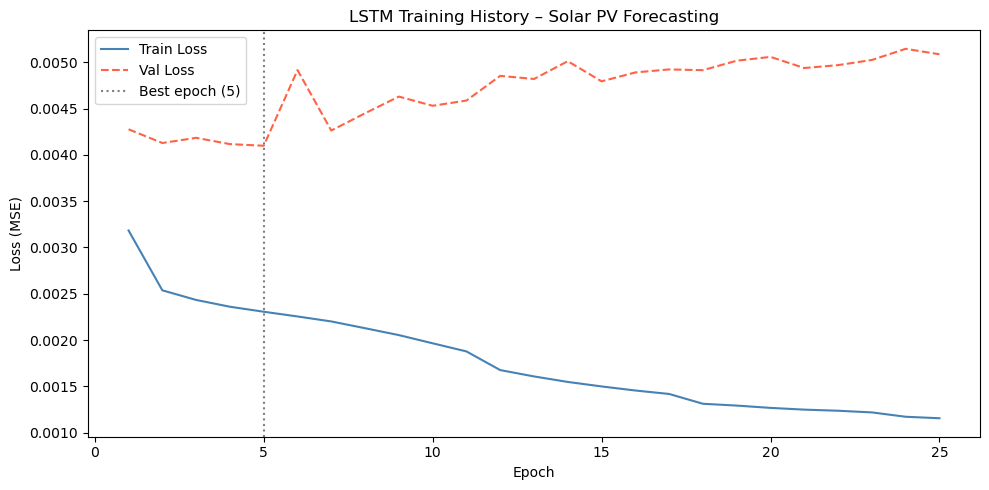

In [59]:
# Test loss
standard_test_loss_p2 = standard_trainer_p2.validate(standard_test_loader_p2)
print(f"Test Loss (MSE): {standard_test_loss_p2:.6f}")

# Collect predictions
model_p2.eval()
predictions_p2, actuals_p2 = [], []

with torch.no_grad():
    for batch_x, batch_s, batch_y in standard_test_loader_p2:
        batch_x = batch_x.to(standard_trainer_p2.device)
        batch_s = batch_s.to(standard_trainer_p2.device)
        predictions_p2.append(model_p2(batch_x, batch_s).cpu().numpy())
        actuals_p2.append(batch_y.cpu().numpy())

predictions_p2 = np.concatenate(predictions_p2, axis=0)
actuals_p2     = np.concatenate(actuals_p2,     axis=0)

print(f"Predictions shape: {predictions_p2.shape}")
print(f"Actuals shape:     {actuals_p2.shape}")

# No denorm needed — already on [0,1] scale
# Per-step metrics
print(f"\n{'Horizon':<10} {'RMSE':<12} {'MAE':<12} {'R²':<10}")
print("-" * 54)
p2_r2_list = []
for h in range(horizon_p2):
    p, a = predictions_p2[:, h], actuals_p2[:, h]
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    r2   = r2_score(a, p)

    p2_r2_list.append(r2)
    print(f"t+{h+1:<8} {rmse:<12.4f} {mae:<12.4f} {r2:<10.4f}")

print("-" * 54)
p_flat, a_flat = predictions_p2.flatten(), actuals_p2.flatten()
print(f"{'Overall':<10} {np.sqrt(mean_squared_error(a_flat, p_flat)):<12.4f} "
      f"{mean_absolute_error(a_flat, p_flat):<12.4f} {r2_score(a_flat, p_flat):<10.4f} ")

train_loss = standard_history_p2['train_loss']
val_loss   = standard_history_p2['val_loss']
epochs     = range(1, len(train_loss) + 1)

# Find where early stopping fired (best val epoch)
best_epoch = val_loss.index(min(val_loss)) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_loss, label='Train Loss', color='steelblue')
ax.plot(epochs, val_loss,   label='Val Loss',   color='tomato', linestyle='--')
ax.axvline(x=best_epoch, color='grey', linestyle=':', label=f'Best epoch ({best_epoch})')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('LSTM Training History – Solar PV Forecasting')
ax.legend()
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [60]:
# Rebuild test sequences with station labels
station_labels = []
for station_id, group in p2LSTM_test.groupby('station_id'):
    pos = p2LSTM_test.index.get_indexer(group.index)
    y_site = p2LSTM_test["powerscaled"].values[pos].reshape(-1, 1)
    timestamps = group['Time'].to_numpy()
    expected_gap = pd.Timedelta(minutes=60)
    
    for i in range(len(y_site) - lookback_steps_p2 - horizon_p2 + 1):
        diffs = np.diff(timestamps[i : i + lookback_steps_p2 + horizon_p2])
        if not all(d == expected_gap for d in diffs):
            continue
        station_labels.append(station_id)

station_labels = np.array(station_labels)
print(f"Labels: {len(station_labels)}, Predictions: {len(predictions_p2)}")  # must match

# Per-station R²
results = []
for sid in np.unique(station_labels):
    mask = station_labels == sid
    a = actuals_p2[mask, 0]
    p = predictions_p2[mask, 0]
    r2 = r2_score(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    cap = p2LSTM_test[p2LSTM_test['station_id'] == sid]['capacity_kw'].iloc[0]
    results.append({'station': sid, 'R2': r2, 'RMSE': rmse, 'capacity_kw': cap, 'n_seq': mask.sum()})

results_df = pd.DataFrame(results).sort_values('R2')
print(results_df.to_string(index=False))

Labels: 131493, Predictions: 131493
                       station       R2     RMSE  capacity_kw  n_seq
            S_H_Ho_Sports_Hall 0.806178 0.035404        42.00   1542
                   UG_Hall2_2F 0.896070 0.024514        23.40   2422
                   UG_Hall2_RF 0.937148 0.037586         8.00   2372
                    SQ_Block_S 0.937235 0.038477        32.85   2422
                       Zone_A1 0.942286 0.038466        33.30   2422
             SQ_Apartment37_48 0.943544 0.032822        16.22   2367
                    SQ_Block_R 0.944171 0.045715        33.30   2422
                           SQ1 0.944946 0.048435        27.60   2422
                       Zone_A2 0.946056 0.039499       249.50   2396
                       Zone_L2 0.946367 0.047942        10.00   2346
                           SQ2 0.946528 0.040875        33.30   2422
                      UG_Hall7 0.946651 0.027486        31.98   2422
             SQ_Apartment13_24 0.946905 0.055758        17.00   239